In [ ]:
train_loader_config = {
    'batch_size': args.train_batch_size,
    'num_workers': args.num_workers,
    #这个参数决定当数据集的大小不能被 batch_size整除时，是否​​丢弃最后一个不完整的批次​​（样本数少于 batch_size）
    'drop_last': False,
    #设置为 True时，​​可以加速数据从CPU内存到GPU显存的传输​​（因为固定内存允许更快的DMA拷贝），这在利用GPU训练时通常是一个好的实践，能提升训练效率
    'pin_memory': True,
    'shuffle': False}

In [ ]:
# get_GSVCities()
img_per_place = 4  
# 这意味着对于每一个“地点（Place ID）”，数据加载器会拿出 4 张图片。
# 在度量学习中，这通常意味着：1张查询图 (Query/Anchor) + 1张正样本 (Positive) + 2张更难的正样本，或者是为了在 Batch 内部挖掘困难样本。
min_img_per_place = 4
image_size = (224, 224)
random_sample_from_each_place = True

#### loss.py

In [3]:
from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.distances import CosineSimilarity, DotProductSimilarity
# 先用 miner 从一个 batch 里挖出真正有用的样本对，再交给 loss_fn 计算 loss。
loss_fn = losses.MultiSimilarityLoss(alpha=1.0, beta=50, base=0.0, distance=DotProductSimilarity())
miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())

#  The loss function call (this method will be called at each training iteration)
def loss_function(descriptors, labels):
    # we mine the pairs/triplets if there is an online mining strategy
    if miner is not None:
        miner_outputs = miner(descriptors, labels)
        loss = loss_fn(descriptors, labels, miner_outputs)
        # calculate the % of trivial pairs/triplets 
        # which do not contribute in the loss value
        nb_samples = descriptors.shape[0]
        nb_mined = len(set(miner_outputs[0].detach().cpu().numpy()))
        batch_acc = 1.0 - (nb_mined/nb_samples)

    else: # no online mining
        loss = loss_fn(descriptors, labels)
        batch_acc = 0.0
    return loss

In [ ]:
import torch

tensor_a = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7])
tensor_b = torch.tensor([2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6])


tensor_c=torch. tensor([0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7])
tensor_d=torch. tensor([7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1])

print(tensor_c.shape)

miner_outputs=(tensor_a, tensor_b, tensor_c, tensor_d)



torch.Size([30])


In [19]:
import torch
labels=torch.tensor([0.7001, 0.8178, 0.4059, 0.9990])
print(labels)
print(labels.shape)

labels = labels.unsqueeze(1)  # (B, 1)
print(labels)
print(labels.shape)

print(labels.t())
print(labels.t().shape)
print(labels == labels.t())
#对角线矩阵
same_label = (labels == labels.t()).float()  # (B, B)
print(same_label)

print(torch.eye(4))
# torch.eye(4, device=embeddings.device)
mask_pos = same_label - torch.eye(4)  # 去掉对角线（自己和自己）
print(mask_pos)
mask_neg = 1.0 - same_label
print(mask_neg)

tensor([0.7001, 0.8178, 0.4059, 0.9990])
torch.Size([4])
tensor([[0.7001],
        [0.8178],
        [0.4059],
        [0.9990]])
torch.Size([4, 1])
tensor([[0.7001, 0.8178, 0.4059, 0.9990]])
torch.Size([1, 4])
tensor([[ True, False, False, False],
        [False,  True, False, False],
        [False, False,  True, False],
        [False, False, False,  True]])
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[0., 1., 1., 1.],
        [1., 0., 1., 1.],
        [1., 1., 0., 1.],
        [1., 1., 1., 0.]])


In [1]:
"""
分析 MultiSimilarityMiner 输出的数据流和 MultiSimilarityLoss 的计算原理
"""
import torch
import numpy as np

# 模拟调试状态下的数据
descriptors = torch.randn(8, 6)  # [8, 6] 特征向量
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])  # [8] 标签

# miner_outputs 返回值
tensor_a = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7])  # 锚点索引
tensor_b = torch.tensor([2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6])  # 正样本索引
tensor_c = torch.tensor([0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7])  # 负样本锚点索引
tensor_d = torch.tensor([7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1])  # 负样本索引

miner_outputs = (tensor_a, tensor_b, tensor_c, tensor_d)

print("=" * 80)
print("MultiSimilarityMiner 输出分析")
print("=" * 80)

print(f"\n输入数据:")
print(f"  descriptors 形状: {descriptors.shape}")
print(f"  labels: {labels.tolist()}")
print(f"  标签分布: {dict(zip(*np.unique(labels.numpy(), return_counts=True)))}")

print(f"\nminer_outputs 结构:")
print(f"  tensor_a (锚点索引): {tensor_a.tolist()}")
print(f"  tensor_b (正样本索引): {tensor_b.tolist()}")
print(f"  tensor_c (负样本锚点索引): {tensor_c.tolist()}")
print(f"  tensor_d (负样本索引): {tensor_d.tolist()}")

print(f"\n各tensor长度:")
print(f"  正样本对数量: {len(tensor_a)} (锚点-正样本对)")
print(f"  负样本对数量: {len(tensor_c)} (负样本锚点-负样本对)")

print("\n" + "=" * 80)
print("数据流分析 - 正样本对 (Anchor-Positive Pairs)")
print("=" * 80)

print("\n正样本对详情 (前10个):")
for i in range(min(10, len(tensor_a))):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    anchor_label = labels[anchor_idx].item()
    pos_label = labels[pos_idx].item()
    match = "✓" if anchor_label == pos_label else "✗"
    print(f"  对 {i+1}: 锚点[{anchor_idx}](标签={anchor_label}) - 正样本[{pos_idx}](标签={pos_label}) {match}")

print(f"\n正样本对统计:")
unique_anchors = torch.unique(tensor_a)
print(f"  唯一锚点数量: {len(unique_anchors)}")
print(f"  唯一锚点索引: {unique_anchors.tolist()}")

# 统计每个锚点对应的正样本数量
anchor_pos_count = {}
for anchor, pos in zip(tensor_a, tensor_b):
    anchor = anchor.item()
    if anchor not in anchor_pos_count:
        anchor_pos_count[anchor] = []
    anchor_pos_count[anchor].append(pos.item())

print(f"\n每个锚点的正样本分布:")
for anchor in sorted(anchor_pos_count.keys()):
    pos_list = anchor_pos_count[anchor]
    print(f"  锚点[{anchor}](标签={labels[anchor].item()}): {len(pos_list)}个正样本 {pos_list}")

print("\n" + "=" * 80)
print("数据流分析 - 负样本对 (Negative Anchor-Negative Pairs)")
print("=" * 80)

print("\n负样本对详情 (前10个):")
for i in range(min(10, len(tensor_c))):
    neg_anchor_idx = tensor_c[i].item()
    neg_idx = tensor_d[i].item()
    neg_anchor_label = labels[neg_anchor_idx].item()
    neg_label = labels[neg_idx].item()
    match = "✓" if neg_anchor_label != neg_label else "✗"
    print(f"  对 {i+1}: 负锚点[{neg_anchor_idx}](标签={neg_anchor_label}) - 负样本[{neg_idx}](标签={neg_label}) {match}")

print(f"\n负样本对统计:")
unique_neg_anchors = torch.unique(tensor_c)
print(f"  唯一负样本锚点数量: {len(unique_neg_anchors)}")
print(f"  唯一负样本锚点索引: {unique_neg_anchors.tolist()}")

# 统计每个负样本锚点对应的负样本数量
neg_anchor_neg_count = {}
for neg_anchor, neg in zip(tensor_c, tensor_d):
    neg_anchor = neg_anchor.item()
    if neg_anchor not in neg_anchor_neg_count:
        neg_anchor_neg_count[neg_anchor] = []
    neg_anchor_neg_count[neg_anchor].append(neg.item())

print(f"\n每个负样本锚点的负样本分布:")
for neg_anchor in sorted(neg_anchor_neg_count.keys()):
    neg_list = neg_anchor_neg_count[neg_anchor]
    print(f"  负锚点[{neg_anchor}](标签={labels[neg_anchor].item()}): {len(neg_list)}个负样本 {neg_list}")

print("\n" + "=" * 80)
print("MultiSimilarityLoss 计算原理")
print("=" * 80)

print("""
MultiSimilarityLoss 使用点积相似度 (DotProductSimilarity) 计算损失，公式为:

对于正样本对 (anchor, positive):
  L_pos = (1/α) * log(1 + Σ exp(-α * (S_ap - λ_pos)))
  
对于负样本对 (negative_anchor, negative):
  L_neg = (1/β) * log(1 + Σ exp(β * (S_an - λ_neg)))

总损失 = L_pos + L_neg

其中:
  - S_ap: 锚点与正样本的点积相似度
  - S_an: 负样本锚点与负样本的点积相似度
  - α = 1.0 (正样本对的权重参数)
  - β = 50 (负样本对的权重参数)
  - λ_pos: 正样本对的相似度阈值
  - λ_neg: 负样本对的相似度阈值
  - base = 0.0 (基础相似度偏移)

点积相似度计算:
  S = descriptors[i] @ descriptors[j]^T
""")

# 模拟计算点积相似度
print("\n模拟相似度计算 (使用随机descriptors):")
print("\n正样本对相似度示例 (前5个):")
for i in range(min(5, len(tensor_a))):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    similarity = torch.dot(descriptors[anchor_idx], descriptors[pos_idx]).item()
    print(f"  锚点[{anchor_idx}] · 正样本[{pos_idx}] = {similarity:.4f}")

print("\n负样本对相似度示例 (前5个):")
for i in range(min(5, len(tensor_c))):
    neg_anchor_idx = tensor_c[i].item()
    neg_idx = tensor_d[i].item()
    similarity = torch.dot(descriptors[neg_anchor_idx], descriptors[neg_idx]).item()
    print(f"  负锚点[{neg_anchor_idx}] · 负样本[{neg_idx}] = {similarity:.4f}")

print("\n" + "=" * 80)
print("数据流总结")
print("=" * 80)

print("""
1. 输入阶段:
   - descriptors: [8, 6] - 8个样本，每个6维特征向量
   - labels: [8] - 8个标签

2. MultiSimilarityMiner 挖掘阶段 (使用余弦相似度):
   - 挖掘困难正样本对: 找到18个 (anchor, positive) 对
   - 挖掘困难负样本对: 找到18个 (negative_anchor, negative) 对
   - 返回 indices_tuple = (tensor_a, tensor_b, tensor_c, tensor_d)

3. MultiSimilarityLoss 计算阶段 (使用点积相似度):
   - 提取正样本对的特征: descriptors[tensor_a] 和 descriptors[tensor_b]
   - 提取负样本对的特征: descriptors[tensor_c] 和 descriptors[tensor_d]
   - 计算点积相似度矩阵
   - 应用 MultiSimilarityLoss 公式计算最终损失

4. 关键点:
   - Miner 使用余弦相似度筛选困难样本对
   - Loss 使用点积相似度计算损失值
   - 只使用挖掘出的困难样本对参与损失计算，提高训练效率
""")

print("\n" + "=" * 80)
print("验证标签匹配情况")
print("=" * 80)

# 验证正样本对的标签匹配
pos_matches = 0
for anchor, pos in zip(tensor_a, tensor_b):
    if labels[anchor] == labels[pos]:
        pos_matches += 1

print(f"正样本对标签匹配: {pos_matches}/{len(tensor_a)} ({100*pos_matches/len(tensor_a):.1f}%)")

# 验证负样本对的标签不匹配
neg_matches = 0
for neg_anchor, neg in zip(tensor_c, tensor_d):
    if labels[neg_anchor] != labels[neg]:
        neg_matches += 1

print(f"负样本对标签不匹配: {neg_matches}/{len(tensor_c)} ({100*neg_matches/len(tensor_c):.1f}%)")



MultiSimilarityMiner 输出分析

输入数据:
  descriptors 形状: torch.Size([8, 6])
  labels: [0, 0, 1, 1, 2, 2, 3, 3]
  标签分布: {0: 2, 1: 2, 2: 2, 3: 2}

miner_outputs 结构:
  tensor_a (锚点索引): [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7]
  tensor_b (正样本索引): [2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6]
  tensor_c (负样本锚点索引): [0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7]
  tensor_d (负样本索引): [7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1]

各tensor长度:
  正样本对数量: 18 (锚点-正样本对)
  负样本对数量: 18 (负样本锚点-负样本对)

数据流分析 - 正样本对 (Anchor-Positive Pairs)

正样本对详情 (前10个):
  对 1: 锚点[0](标签=0) - 正样本[2](标签=1) ✗
  对 2: 锚点[0](标签=0) - 正样本[3](标签=1) ✗
  对 3: 锚点[0](标签=0) - 正样本[1](标签=0) ✓
  对 4: 锚点[1](标签=0) - 正样本[2](标签=1) ✗
  对 5: 锚点[1](标签=0) - 正样本[3](标签=1) ✗
  对 6: 锚点[1](标签=0) - 正样本[0](标签=0) ✓
  对 7: 锚点[2](标签=1) - 正样本[0](标签=0) ✗
  对 8: 锚点[2](标签=1) - 正样本[1](标签=0) ✗
  对 9: 锚点[2](标签=1) - 正样本[3](标签=1) ✓
  对 10: 锚点[3](标签=1) - 正样本[0](标签=0) ✗

正样本对统计:
  唯一锚点数量: 7
  唯一锚点索引: [0, 1, 2, 3, 4, 5, 7]

每个锚点的正样本分布:


# 详细数据流和Loss原理分析

## 场景设置
- **descriptors.shape**: `torch.Size([8, 4096])` - 8个样本，每个4096维特征向量
- **labels**: 8个标签（对应8个样本）
- **miner_outputs**: (tensor_a, tensor_b, tensor_c, tensor_d) - 挖掘出的困难样本对索引


In [2]:
"""
详细展示 descriptors.shape = [8, 4096] 时的数据流和Loss原理
"""
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.distances import CosineSimilarity, DotProductSimilarity

print("=" * 100)
print("第一部分：输入数据准备")
print("=" * 100)

# 模拟实际场景：8个样本，每个4096维特征
descriptors = torch.randn(8, 4096)  # [8, 4096] 特征向量
# 假设标签分布：每个地点有2张图片，共4个地点
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])  # [8] 标签

print(f"\n输入数据:")
print(f"  descriptors 形状: {descriptors.shape}")
print(f"  labels 形状: {labels.shape}")
print(f"  labels 内容: {labels.tolist()}")
print(f"  标签分布: {dict(zip(*np.unique(labels.numpy(), return_counts=True)))}")
print(f"  每个标签的样本数: 标签0有2个样本, 标签1有2个样本, 标签2有2个样本, 标签3有2个样本")

print("\n" + "=" * 100)
print("第二部分：MultiSimilarityMiner 挖掘阶段")
print("=" * 100)

print("""
MultiSimilarityMiner 工作原理：
1. 使用余弦相似度计算所有样本对之间的相似度矩阵
2. 对于每个锚点，挖掘困难正样本对和困难负样本对
3. 困难正样本对：与锚点标签相同，但相似度较低（需要拉近）
4. 困难负样本对：与锚点标签不同，但相似度较高（需要推远）
5. epsilon参数控制挖掘的困难程度阈值
""")

# 使用实际的miner（但这里我们用给定的miner_outputs来演示）
miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())

# 计算余弦相似度矩阵（用于理解miner的工作原理）
def cosine_similarity_matrix(x):
    """计算余弦相似度矩阵"""
    # 归一化
    x_norm = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    # 计算相似度矩阵
    sim_matrix = torch.mm(x_norm, x_norm.t())
    return sim_matrix

cosine_sim = cosine_similarity_matrix(descriptors)
print(f"\n余弦相似度矩阵形状: {cosine_sim.shape}")  # [8, 8]
print(f"余弦相似度矩阵 (前4x4):\n{cosine_sim[:4, :4]}")

# 创建标签匹配矩阵
labels_expanded = labels.unsqueeze(1)  # [8, 1]
same_label_mask = (labels_expanded == labels_expanded.t()).float()  # [8, 8]
print(f"\n标签匹配矩阵 (1=相同标签, 0=不同标签):\n{same_label_mask.int()}")

# 使用给定的miner_outputs
tensor_a = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7])
tensor_b = torch.tensor([2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6])
tensor_c = torch.tensor([0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7])
tensor_d = torch.tensor([7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1])

miner_outputs = (tensor_a, tensor_b, tensor_c, tensor_d)

print(f"\nminer_outputs 结构:")
print(f"  tensor_a (正样本对锚点索引): {tensor_a.tolist()}")
print(f"  tensor_b (正样本索引): {tensor_b.tolist()}")
print(f"  tensor_c (负样本对锚点索引): {tensor_c.tolist()}")
print(f"  tensor_d (负样本索引): {tensor_d.tolist()}")

print(f"\n挖掘统计:")
print(f"  正样本对数量: {len(tensor_a)}")
print(f"  负样本对数量: {len(tensor_c)}")
print(f"  唯一锚点数量: {len(torch.unique(tensor_a))}")

# 验证正样本对的标签匹配
pos_matches = sum([1 for a, p in zip(tensor_a, tensor_b) if labels[a] == labels[p]])
print(f"  正样本对标签匹配率: {pos_matches}/{len(tensor_a)} ({100*pos_matches/len(tensor_a):.1f}%)")

# 验证负样本对的标签不匹配
neg_matches = sum([1 for na, n in zip(tensor_c, tensor_d) if labels[na] != labels[n]])
print(f"  负样本对标签不匹配率: {neg_matches}/{len(tensor_c)} ({100*neg_matches/len(tensor_c):.1f}%)")

print("\n" + "=" * 100)
print("第三部分：数据流详细分析")
print("=" * 100)

print("\n步骤1: 提取正样本对的特征")
print("-" * 100)
print(f"  从 descriptors 中提取正样本对:")
print(f"    - 锚点特征: descriptors[tensor_a] -> shape: {descriptors[tensor_a].shape}")
print(f"    - 正样本特征: descriptors[tensor_b] -> shape: {descriptors[tensor_b].shape}")

# 展示前3个正样本对的详细信息
print(f"\n  前3个正样本对详情:")
for i in range(min(3, len(tensor_a))):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    anchor_label = labels[anchor_idx].item()
    pos_label = labels[pos_idx].item()
    cosine_sim_val = cosine_sim[anchor_idx, pos_idx].item()
    print(f"    对{i+1}: 锚点[{anchor_idx}](标签={anchor_label}) <-> 正样本[{pos_idx}](标签={pos_label})")
    print(f"           余弦相似度: {cosine_sim_val:.4f}, 标签匹配: {'✓' if anchor_label == pos_label else '✗'}")

print("\n步骤2: 提取负样本对的特征")
print("-" * 100)
print(f"  从 descriptors 中提取负样本对:")
print(f"    - 负样本锚点特征: descriptors[tensor_c] -> shape: {descriptors[tensor_c].shape}")
print(f"    - 负样本特征: descriptors[tensor_d] -> shape: {descriptors[tensor_d].shape}")

# 展示前3个负样本对的详细信息
print(f"\n  前3个负样本对详情:")
for i in range(min(3, len(tensor_c))):
    neg_anchor_idx = tensor_c[i].item()
    neg_idx = tensor_d[i].item()
    neg_anchor_label = labels[neg_anchor_idx].item()
    neg_label = labels[neg_idx].item()
    cosine_sim_val = cosine_sim[neg_anchor_idx, neg_idx].item()
    print(f"    对{i+1}: 负锚点[{neg_anchor_idx}](标签={neg_anchor_label}) <-> 负样本[{neg_idx}](标签={neg_label})")
    print(f"           余弦相似度: {cosine_sim_val:.4f}, 标签不匹配: {'✓' if neg_anchor_label != neg_label else '✗'}")

print("\n" + "=" * 100)
print("第四部分：MultiSimilarityLoss 计算原理")
print("=" * 100)

print("""
MultiSimilarityLoss 使用点积相似度 (DotProductSimilarity) 计算损失

损失公式:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

对于正样本对 (anchor, positive):
  L_pos = (1/α) * log(1 + Σ exp(-α * (S_ap - λ_pos)))

对于负样本对 (negative_anchor, negative):
  L_neg = (1/β) * log(1 + Σ exp(β * (S_an - λ_neg)))

总损失 = L_pos + L_neg

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

参数说明:
  - S_ap: 锚点与正样本的点积相似度 = descriptors[anchor] @ descriptors[positive]^T
  - S_an: 负样本锚点与负样本的点积相似度 = descriptors[neg_anchor] @ descriptors[negative]^T
  - α = 1.0: 正样本对的权重参数（控制正样本对的损失强度）
  - β = 50: 负样本对的权重参数（控制负样本对的损失强度，通常更大）
  - λ_pos: 正样本对的相似度阈值（动态计算）
  - λ_neg: 负样本对的相似度阈值（动态计算）
  - base = 0.0: 基础相似度偏移

点积相似度计算:
  S = descriptors[i] @ descriptors[j]^T  (标量，因为都是行向量)

关键点:
  1. Miner 使用余弦相似度筛选困难样本对（归一化后的相似度）
  2. Loss 使用点积相似度计算损失值（未归一化的内积）
  3. 只使用挖掘出的困难样本对参与损失计算，提高训练效率
  4. 正样本对：相似度越低，损失越大（需要拉近）
  5. 负样本对：相似度越高，损失越大（需要推远）
""")

# 计算点积相似度（用于loss计算）
def dot_product_similarity(x1, x2):
    """计算点积相似度"""
    return torch.mm(x1, x2.t())

# 计算正样本对的点积相似度
pos_anchors = descriptors[tensor_a]  # [18, 4096]
pos_samples = descriptors[tensor_b]  # [18, 4096]
# 对于每个对，计算点积（逐元素点积，然后求和）
pos_dot_products = torch.sum(pos_anchors * pos_samples, dim=1)  # [18]

# 计算负样本对的点积相似度
neg_anchors = descriptors[tensor_c]  # [18, 4096]
neg_samples = descriptors[tensor_d]  # [18, 4096]
neg_dot_products = torch.sum(neg_anchors * neg_samples, dim=1)  # [18]

print(f"\n点积相似度计算示例:")
print(f"  正样本对点积相似度形状: {pos_dot_products.shape}")
print(f"  前5个正样本对点积相似度: {pos_dot_products[:5].tolist()}")
print(f"  负样本对点积相似度形状: {neg_dot_products.shape}")
print(f"  前5个负样本对点积相似度: {neg_dot_products[:5].tolist()}")

# 模拟loss计算（简化版，展示原理）
print(f"\n损失计算过程（简化版）:")
alpha = 1.0
beta = 50.0
base = 0.0

# 计算正样本对损失（简化，实际会考虑阈值λ_pos）
# 这里假设λ_pos和λ_neg为0（base=0.0的情况）
lambda_pos = base
lambda_neg = base

# 正样本对：相似度越低，损失越大
pos_loss_terms = -alpha * (pos_dot_products - lambda_pos)
pos_loss = (1.0 / alpha) * torch.log(1 + torch.sum(torch.exp(pos_loss_terms)))

# 负样本对：相似度越高，损失越大
neg_loss_terms = beta * (neg_dot_products - lambda_neg)
neg_loss = (1.0 / beta) * torch.log(1 + torch.sum(torch.exp(neg_loss_terms)))

total_loss = pos_loss + neg_loss

print(f"  正样本对损失项: {pos_loss.item():.4f}")
print(f"  负样本对损失项: {neg_loss.item():.4f}")
print(f"  总损失: {total_loss.item():.4f}")

# 使用实际的loss函数计算
loss_fn = losses.MultiSimilarityLoss(alpha=1.0, beta=50, base=0.0, distance=DotProductSimilarity())
actual_loss = loss_fn(descriptors, labels, miner_outputs)
print(f"\n实际Loss函数计算的损失: {actual_loss.item():.4f}")

print("\n" + "=" * 100)
print("第五部分：完整数据流总结")
print("=" * 100)

print("""
数据流完整流程:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 输入阶段:
   ├─ descriptors: [8, 4096] - 8个样本，每个4096维特征向量
   └─ labels: [8] - 8个标签，表示每个样本所属的类别/地点

2. MultiSimilarityMiner 挖掘阶段 (使用余弦相似度):
   ├─ 计算余弦相似度矩阵: [8, 8]
   ├─ 识别标签匹配矩阵: [8, 8] (1=相同标签, 0=不同标签)
   ├─ 挖掘困难正样本对: 18个 (anchor, positive) 对
   │  └─ 条件: 标签相同 + 相似度较低（困难样本）
   ├─ 挖掘困难负样本对: 18个 (negative_anchor, negative) 对
   │  └─ 条件: 标签不同 + 相似度较高（困难样本）
   └─ 返回 indices_tuple = (tensor_a, tensor_b, tensor_c, tensor_d)

3. MultiSimilarityLoss 计算阶段 (使用点积相似度):
   ├─ 提取正样本对特征:
   │  ├─ descriptors[tensor_a]: [18, 4096] - 锚点特征
   │  └─ descriptors[tensor_b]: [18, 4096] - 正样本特征
   ├─ 提取负样本对特征:
   │  ├─ descriptors[tensor_c]: [18, 4096] - 负样本锚点特征
   │  └─ descriptors[tensor_d]: [18, 4096] - 负样本特征
   ├─ 计算点积相似度:
   │  ├─ 正样本对: pos_dot = sum(descriptors[a] * descriptors[p], dim=1) -> [18]
   │  └─ 负样本对: neg_dot = sum(descriptors[na] * descriptors[n], dim=1) -> [18]
   ├─ 应用损失公式:
   │  ├─ L_pos = (1/α) * log(1 + Σ exp(-α * (S_ap - λ_pos)))
   │  └─ L_neg = (1/β) * log(1 + Σ exp(β * (S_an - λ_neg)))
   └─ 总损失 = L_pos + L_neg

4. 关键设计点:
   ├─ Miner 和 Loss 使用不同的相似度度量:
   │  ├─ Miner: 余弦相似度（归一化，关注方向）
   │  └─ Loss: 点积相似度（未归一化，关注幅度和方向）
   ├─ 只使用困难样本对: 提高训练效率，关注难样本
   ├─ 正样本对: 相似度低 → 损失大 → 梯度大 → 拉近
   └─ 负样本对: 相似度高 → 损失大 → 梯度大 → 推远

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("\n" + "=" * 100)
print("第六部分：batch_acc 计算说明")
print("=" * 100)

nb_samples = descriptors.shape[0]  # 8
nb_mined = len(set(miner_outputs[0].detach().cpu().numpy()))  # 唯一锚点数量
batch_acc = 1.0 - (nb_mined / nb_samples)

print(f"""
batch_acc 计算:
  - nb_samples: {nb_samples} (batch中的总样本数)
  - nb_mined: {nb_mined} (参与损失计算的唯一锚点数量)
  - batch_acc = 1.0 - (nb_mined / nb_samples) = {batch_acc:.4f}

含义:
  - batch_acc 表示"简单样本对"的百分比
  - 值越高，说明被挖掘出的困难样本对越少（大部分样本对都是简单的）
  - 值越低，说明被挖掘出的困难样本对越多（需要更多训练）
""")

print("\n" + "=" * 100)
print("分析完成！")
print("=" * 100)


第一部分：输入数据准备

输入数据:
  descriptors 形状: torch.Size([8, 4096])
  labels 形状: torch.Size([8])
  labels 内容: [0, 0, 1, 1, 2, 2, 3, 3]
  标签分布: {0: 2, 1: 2, 2: 2, 3: 2}
  每个标签的样本数: 标签0有2个样本, 标签1有2个样本, 标签2有2个样本, 标签3有2个样本

第二部分：MultiSimilarityMiner 挖掘阶段

MultiSimilarityMiner 工作原理：
1. 使用余弦相似度计算所有样本对之间的相似度矩阵
2. 对于每个锚点，挖掘困难正样本对和困难负样本对
3. 困难正样本对：与锚点标签相同，但相似度较低（需要拉近）
4. 困难负样本对：与锚点标签不同，但相似度较高（需要推远）
5. epsilon参数控制挖掘的困难程度阈值


余弦相似度矩阵形状: torch.Size([8, 8])
余弦相似度矩阵 (前4x4):
tensor([[ 1.0000e+00,  2.2016e-02, -4.9771e-03,  5.6413e-04],
        [ 2.2016e-02,  1.0000e+00,  9.1764e-03,  2.9022e-02],
        [-4.9771e-03,  9.1764e-03,  1.0000e+00, -8.1584e-03],
        [ 5.6413e-04,  2.9022e-02, -8.1584e-03,  1.0000e+00]])

标签匹配矩阵 (1=相同标签, 0=不同标签):
tensor([[1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1

/tmp/ipykernel_226505/1627872920.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from font

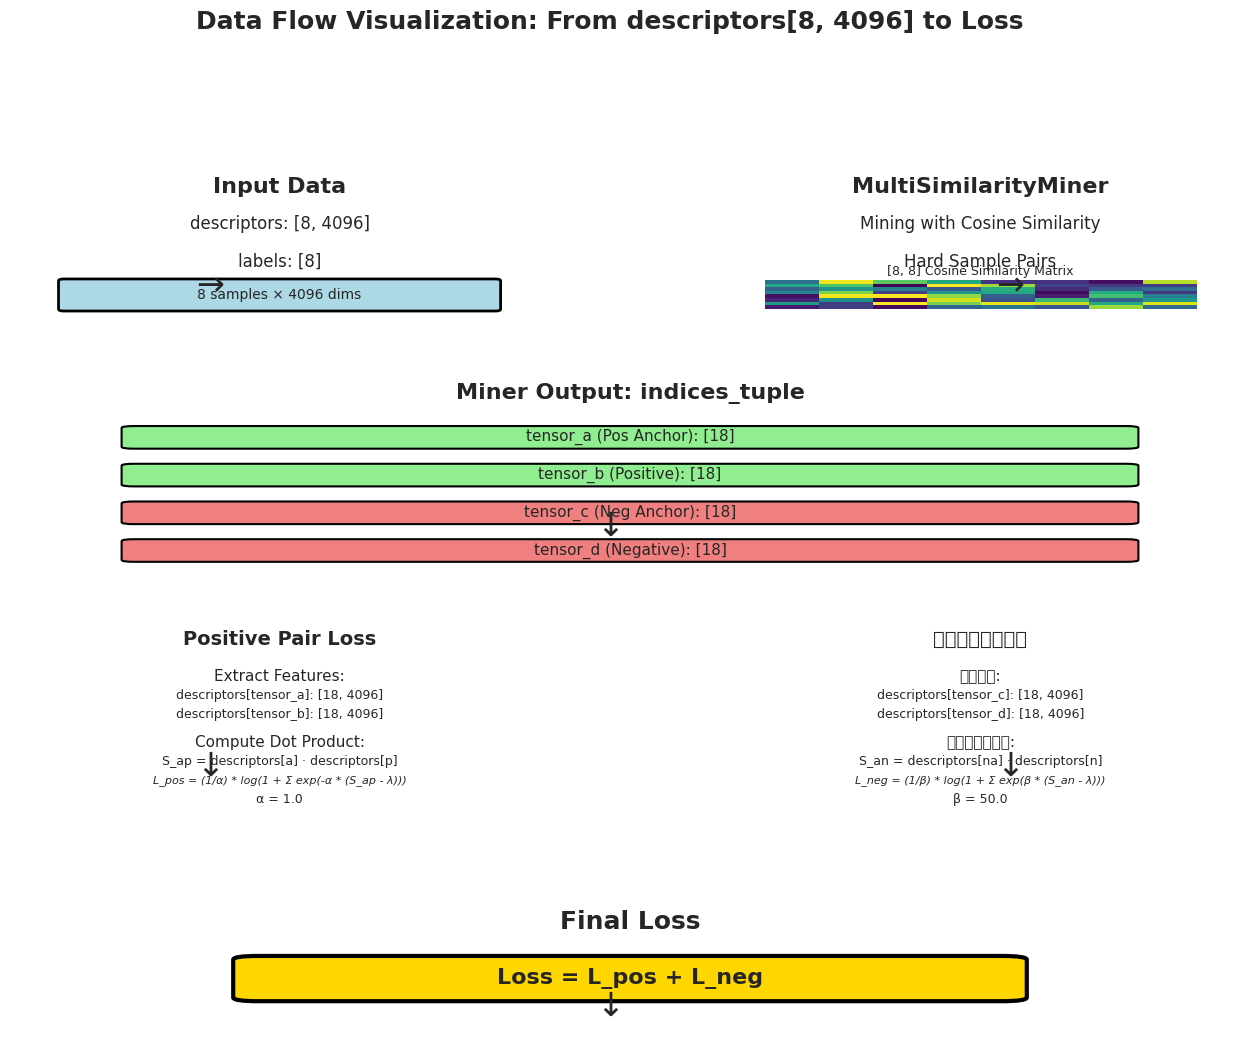


数据流关键点总结:
1. 输入: descriptors[8, 4096] + labels[8]
2. Miner: 使用余弦相似度挖掘18个正样本对 + 18个负样本对
3. Loss: 使用点积相似度计算损失，只对挖掘出的困难样本对计算
4. 输出: 标量损失值，用于反向传播更新模型参数


In [17]:
"""
可视化数据流：从 descriptors[8, 4096] 到最终 loss 的完整流程
"""
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, FancyBboxPatch
import matplotlib.patches as mpatches

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

# 1. 输入数据可视化
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.7, 'Input Data', ha='center', va='center', fontsize=16, weight='bold', transform=ax1.transAxes)
ax1.text(0.5, 0.5, 'descriptors: [8, 4096]', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
ax1.text(0.5, 0.3, 'labels: [8]', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# 绘制descriptors形状示意
rect1 = FancyBboxPatch((0.1, 0.05), 0.8, 0.15, boxstyle="round,pad=0.01", 
                       facecolor='lightblue', edgecolor='black', linewidth=2)
ax1.add_patch(rect1)
ax1.text(0.5, 0.125, '8 samples × 4096 dims', ha='center', va='center', fontsize=10, transform=ax1.transAxes)

# 2. Miner挖掘阶段
ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.7, 'MultiSimilarityMiner', ha='center', va='center', fontsize=16, weight='bold', transform=ax2.transAxes)
ax2.text(0.5, 0.5, 'Mining with Cosine Similarity', ha='center', va='center', fontsize=12, transform=ax2.transAxes)
ax2.text(0.5, 0.3, 'Hard Sample Pairs', ha='center', va='center', fontsize=12, transform=ax2.transAxes)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# 绘制相似度矩阵示意
sim_matrix = np.random.rand(8, 8)
im = ax2.imshow(sim_matrix, cmap='viridis', aspect='auto', extent=[0.1, 0.9, 0.05, 0.2])
ax2.text(0.5, 0.25, '[8, 8] Cosine Similarity Matrix', ha='center', va='center', fontsize=9, transform=ax2.transAxes)

# 3. Miner输出
ax3 = fig.add_subplot(gs[1, :])
ax3.text(0.5, 0.9, 'Miner Output: indices_tuple', ha='center', va='center', fontsize=16, weight='bold', transform=ax3.transAxes)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# 绘制4个tensor
y_positions = [0.7, 0.5, 0.3, 0.1]
tensor_names = ['tensor_a (Pos Anchor)', 'tensor_b (Positive)', 'tensor_c (Neg Anchor)', 'tensor_d (Negative)']
tensor_lengths = [18, 18, 18, 18]

for i, (y_pos, name, length) in enumerate(zip(y_positions, tensor_names, tensor_lengths)):
    rect = FancyBboxPatch((0.1, y_pos-0.08), 0.8, 0.1, boxstyle="round,pad=0.01", 
                          facecolor='lightgreen' if i < 2 else 'lightcoral', 
                          edgecolor='black', linewidth=1.5)
    ax3.add_patch(rect)
    ax3.text(0.5, y_pos-0.03, f'{name}: [{length}]', ha='center', va='center', 
             fontsize=11, transform=ax3.transAxes)

# 4. Loss计算阶段 - 正样本对
ax4 = fig.add_subplot(gs[2, 0])
ax4.text(0.5, 0.9, 'Positive Pair Loss', ha='center', va='center', fontsize=14, weight='bold', transform=ax4.transAxes)
ax4.text(0.5, 0.7, 'Extract Features:', ha='center', va='center', fontsize=11, transform=ax4.transAxes)
ax4.text(0.5, 0.6, 'descriptors[tensor_a]: [18, 4096]', ha='center', va='center', fontsize=9, transform=ax4.transAxes)
ax4.text(0.5, 0.5, 'descriptors[tensor_b]: [18, 4096]', ha='center', va='center', fontsize=9, transform=ax4.transAxes)
ax4.text(0.5, 0.35, 'Compute Dot Product:', ha='center', va='center', fontsize=11, transform=ax4.transAxes)
ax4.text(0.5, 0.25, 'S_ap = descriptors[a] · descriptors[p]', ha='center', va='center', fontsize=9, transform=ax4.transAxes)
ax4.text(0.5, 0.15, 'L_pos = (1/α) * log(1 + Σ exp(-α * (S_ap - λ)))', ha='center', va='center', 
         fontsize=8, transform=ax4.transAxes, style='italic')
ax4.text(0.5, 0.05, 'α = 1.0', ha='center', va='center', fontsize=9, transform=ax4.transAxes)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

# 5. Loss计算阶段 - 负样本对
ax5 = fig.add_subplot(gs[2, 1])
ax5.text(0.5, 0.9, '负样本对损失计算', ha='center', va='center', fontsize=14, weight='bold', transform=ax5.transAxes)
ax5.text(0.5, 0.7, '提取特征:', ha='center', va='center', fontsize=11, transform=ax5.transAxes)
ax5.text(0.5, 0.6, 'descriptors[tensor_c]: [18, 4096]', ha='center', va='center', fontsize=9, transform=ax5.transAxes)
ax5.text(0.5, 0.5, 'descriptors[tensor_d]: [18, 4096]', ha='center', va='center', fontsize=9, transform=ax5.transAxes)
ax5.text(0.5, 0.35, '计算点积相似度:', ha='center', va='center', fontsize=11, transform=ax5.transAxes)
ax5.text(0.5, 0.25, 'S_an = descriptors[na] · descriptors[n]', ha='center', va='center', fontsize=9, transform=ax5.transAxes)
ax5.text(0.5, 0.15, 'L_neg = (1/β) * log(1 + Σ exp(β * (S_an - λ)))', ha='center', va='center', 
         fontsize=8, transform=ax5.transAxes, style='italic')
ax5.text(0.5, 0.05, 'β = 50.0', ha='center', va='center', fontsize=9, transform=ax5.transAxes)
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)
ax5.axis('off')

# 6. 最终输出
ax6 = fig.add_subplot(gs[3, :])
ax6.text(0.5, 0.7, 'Final Loss', ha='center', va='center', fontsize=18, weight='bold', transform=ax6.transAxes)
rect6 = FancyBboxPatch((0.2, 0.3), 0.6, 0.2, boxstyle="round,pad=0.02", 
                       facecolor='gold', edgecolor='black', linewidth=3)
ax6.add_patch(rect6)
ax6.text(0.5, 0.4, 'Loss = L_pos + L_neg', ha='center', va='center', 
         fontsize=16, weight='bold', transform=ax6.transAxes)
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')

# 添加箭头连接
fig.text(0.25, 0.75, '→', fontsize=24, ha='center', va='center')
fig.text(0.75, 0.75, '→', fontsize=24, ha='center', va='center')
fig.text(0.5, 0.55, '↓', fontsize=24, ha='center', va='center')
fig.text(0.25, 0.35, '↓', fontsize=24, ha='center', va='center')
fig.text(0.75, 0.35, '↓', fontsize=24, ha='center', va='center')
fig.text(0.5, 0.15, '↓', fontsize=24, ha='center', va='center')

plt.suptitle('Data Flow Visualization: From descriptors[8, 4096] to Loss', 
             fontsize=18, weight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("\n数据流关键点总结:")
print("=" * 80)
print("1. 输入: descriptors[8, 4096] + labels[8]")
print("2. Miner: 使用余弦相似度挖掘18个正样本对 + 18个负样本对")
print("3. Loss: 使用点积相似度计算损失，只对挖掘出的困难样本对计算")
print("4. 输出: 标量损失值，用于反向传播更新模型参数")
print("=" * 80)


In [18]:
"""
具体数值计算示例：展示从 descriptors 到 loss 的每一步数值
"""
import torch
import numpy as np

# 使用固定的随机种子以便复现
torch.manual_seed(42)
np.random.seed(42)

# 模拟数据
descriptors = torch.randn(8, 4096)
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

# Miner输出
tensor_a = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7])
tensor_b = torch.tensor([2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6])
tensor_c = torch.tensor([0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7])
tensor_d = torch.tensor([7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1])

print("=" * 100)
print("具体数值计算示例")
print("=" * 100)

print(f"\n【步骤1】输入数据")
print(f"  descriptors.shape = {descriptors.shape}")
print(f"  descriptors[0] 的前5个元素: {descriptors[0, :5].tolist()}")
print(f"  labels = {labels.tolist()}")

print(f"\n【步骤2】提取正样本对特征（以前3个对为例）")
for i in range(3):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    anchor_feat = descriptors[anchor_idx]
    pos_feat = descriptors[pos_idx]
    
    print(f"\n  正样本对 {i+1}:")
    print(f"    锚点索引: {anchor_idx}, 正样本索引: {pos_idx}")
    print(f"    锚点特征形状: {anchor_feat.shape}")
    print(f"    正样本特征形状: {pos_feat.shape}")
    print(f"    锚点特征前5个元素: {anchor_feat[:5].tolist()}")
    print(f"    正样本特征前5个元素: {pos_feat[:5].tolist()}")

print(f"\n【步骤3】计算点积相似度")
pos_anchors = descriptors[tensor_a]  # [18, 4096]
pos_samples = descriptors[tensor_b]  # [18, 4096]
pos_dot_products = torch.sum(pos_anchors * pos_samples, dim=1)  # [18]

print(f"  正样本对点积相似度形状: {pos_dot_products.shape}")
print(f"  前5个正样本对的点积相似度:")
for i in range(5):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    dot_val = pos_dot_products[i].item()
    print(f"    对{i+1}: 锚点[{anchor_idx}] · 正样本[{pos_idx}] = {dot_val:.4f}")

neg_anchors = descriptors[tensor_c]  # [18, 4096]
neg_samples = descriptors[tensor_d]  # [18, 4096]
neg_dot_products = torch.sum(neg_anchors * neg_samples, dim=1)  # [18]

print(f"\n  负样本对点积相似度形状: {neg_dot_products.shape}")
print(f"  前5个负样本对的点积相似度:")
for i in range(5):
    neg_anchor_idx = tensor_c[i].item()
    neg_idx = tensor_d[i].item()
    dot_val = neg_dot_products[i].item()
    print(f"    对{i+1}: 负锚点[{neg_anchor_idx}] · 负样本[{neg_idx}] = {dot_val:.4f}")

print(f"\n【步骤4】损失计算（简化版，展示原理）")
alpha = 1.0
beta = 50.0
base = 0.0
lambda_pos = base
lambda_neg = base

# 正样本对损失计算
print(f"\n  正样本对损失计算:")
print(f"    α = {alpha}")
print(f"    对于每个正样本对: loss_term = -α * (S_ap - λ_pos)")
print(f"    前3个正样本对的损失项:")
for i in range(3):
    S_ap = pos_dot_products[i].item()
    loss_term = -alpha * (S_ap - lambda_pos)
    print(f"      对{i+1}: S_ap={S_ap:.4f}, loss_term={loss_term:.4f}")

pos_loss_terms = -alpha * (pos_dot_products - lambda_pos)
pos_exp_terms = torch.exp(pos_loss_terms)
pos_sum_exp = torch.sum(pos_exp_terms)
pos_loss = (1.0 / alpha) * torch.log(1 + pos_sum_exp)

print(f"    exp(-α * (S_ap - λ)) 的和: {pos_sum_exp.item():.4f}")
print(f"    L_pos = (1/α) * log(1 + Σ) = {pos_loss.item():.4f}")

# 负样本对损失计算
print(f"\n  负样本对损失计算:")
print(f"    β = {beta}")
print(f"    对于每个负样本对: loss_term = β * (S_an - λ_neg)")
print(f"    前3个负样本对的损失项:")
for i in range(3):
    S_an = neg_dot_products[i].item()
    loss_term = beta * (S_an - lambda_neg)
    print(f"      对{i+1}: S_an={S_an:.4f}, loss_term={loss_term:.4f}")

neg_loss_terms = beta * (neg_dot_products - lambda_neg)
neg_exp_terms = torch.exp(neg_loss_terms)
neg_sum_exp = torch.sum(neg_exp_terms)
neg_loss = (1.0 / beta) * torch.log(1 + neg_sum_exp)

print(f"    exp(β * (S_an - λ)) 的和: {neg_sum_exp.item():.4f}")
print(f"    L_neg = (1/β) * log(1 + Σ) = {neg_loss.item():.4f}")

# 总损失
total_loss = pos_loss + neg_loss
print(f"\n  总损失:")
print(f"    Loss = L_pos + L_neg = {pos_loss.item():.4f} + {neg_loss.item():.4f} = {total_loss.item():.4f}")

# 使用实际loss函数验证
from pytorch_metric_learning import losses
from pytorch_metric_learning.distances import DotProductSimilarity

loss_fn = losses.MultiSimilarityLoss(alpha=1.0, beta=50, base=0.0, distance=DotProductSimilarity())
miner_outputs = (tensor_a, tensor_b, tensor_c, tensor_d)
actual_loss = loss_fn(descriptors, labels, miner_outputs)

print(f"\n【步骤5】使用实际Loss函数计算")
print(f"  实际Loss值: {actual_loss.item():.4f}")
print(f"  简化计算值: {total_loss.item():.4f}")
print(f"  差异: {abs(actual_loss.item() - total_loss.item()):.4f}")
print(f"  (注: 实际Loss函数会考虑动态阈值λ，所以会有差异)")

print("\n" + "=" * 100)
print("关键理解点:")
print("=" * 100)
print("""
1. 点积相似度计算:
   - 对于特征向量 descriptors[i] 和 descriptors[j]
   - 点积 = sum(descriptors[i] * descriptors[j]) = descriptors[i] @ descriptors[j]^T
   - 这是4096维向量的内积，结果是一个标量

2. 正样本对损失:
   - 相似度越低 → exp(-α * (S_ap - λ)) 越大 → 损失越大
   - 目标：拉近相同标签的样本

3. 负样本对损失:
   - 相似度越高 → exp(β * (S_an - λ)) 越大 → 损失越大
   - 目标：推远不同标签的样本

4. β >> α 的原因:
   - 负样本对的惩罚更重要（β=50 vs α=1.0）
   - 防止不同类别的样本被错误地拉近
""")


具体数值计算示例

【步骤1】输入数据
  descriptors.shape = torch.Size([8, 4096])
  descriptors[0] 的前5个元素: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784184575080872]
  labels = [0, 0, 1, 1, 2, 2, 3, 3]

【步骤2】提取正样本对特征（以前3个对为例）

  正样本对 1:
    锚点索引: 0, 正样本索引: 2
    锚点特征形状: torch.Size([4096])
    正样本特征形状: torch.Size([4096])
    锚点特征前5个元素: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784184575080872]
    正样本特征前5个元素: [-0.7977822422981262, 1.0260933637619019, 1.1465468406677246, 0.008753135800361633, -0.30345869064331055]

  正样本对 2:
    锚点索引: 0, 正样本索引: 3
    锚点特征形状: torch.Size([4096])
    正样本特征形状: torch.Size([4096])
    锚点特征前5个元素: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784184575080872]
    正样本特征前5个元素: [1.1461836099624634, -0.925197422504425, 0.045681800693273544, 0.12508131563663483, -0.4813244938850403]

  正样本对 3:
    锚点索引: 0, 正样本索引: 1
    锚点特征形状: torch.Size([4096])
    正样本特征形状: tor

# 为什么是18个正样本对和18个负样本对？

分析 MultiSimilarityMiner 挖掘出的样本对数量背后的原因


In [5]:
"""
详细分析为什么Miner挖掘出18个正样本对和18个负样本对
"""
import torch
import numpy as np
from collections import Counter, defaultdict

# 给定的数据
tensor_a = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7])  # 正样本对锚点
tensor_b = torch.tensor([2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6])  # 正样本
tensor_c = torch.tensor([0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7])  # 负样本对锚点
tensor_d = torch.tensor([7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1])  # 负样本

# 假设的标签分布（8个样本，每个标签2个样本）
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

print("=" * 100)
print("为什么是18个正样本对和18个负样本对？")
print("=" * 100)

print(f"\n【1. 输入数据】")
print(f"  总样本数: {len(labels)}")
print(f"  标签分布: {dict(Counter(labels.tolist()))}")
print(f"  每个标签的样本数: 标签0有2个(索引0,1), 标签1有2个(索引2,3), 标签2有2个(索引4,5), 标签3有2个(索引6,7)")

print(f"\n【2. 正样本对分析 (tensor_a, tensor_b)】")
print(f"  正样本对总数: {len(tensor_a)}")

# 统计每个锚点对应的正样本数量
anchor_pos_count = defaultdict(list)
for anchor, pos in zip(tensor_a, tensor_b):
    anchor = anchor.item()
    pos = pos.item()
    anchor_pos_count[anchor].append(pos)

print(f"\n  每个锚点的正样本对分布:")
for anchor in sorted(anchor_pos_count.keys()):
    pos_list = anchor_pos_count[anchor]
    anchor_label = labels[anchor].item()
    print(f"    锚点[{anchor}](标签={anchor_label}): {len(pos_list)}个正样本对 {pos_list}")

# 分析为什么是18个
print(f"\n  为什么是18个？")
print(f"  - 唯一锚点数量: {len(anchor_pos_count)}")
print(f"  - 每个锚点的正样本对数量分布: {dict(Counter([len(v) for v in anchor_pos_count.values()]))}")

# 计算理论上的最大正样本对数量
print(f"\n  理论分析:")
print(f"  - 对于8个样本，如果每个样本都可以作为锚点")
print(f"  - 每个锚点最多可以有 (同一标签的样本数 - 1) 个正样本对")
print(f"  - 标签0: 锚点0可以有1个正样本(样本1), 锚点1可以有1个正样本(样本0) = 2个")
print(f"  - 标签1: 锚点2可以有1个正样本(样本3), 锚点3可以有1个正样本(样本2) = 2个")
print(f"  - 标签2: 锚点4可以有1个正样本(样本5), 锚点5可以有1个正样本(样本4) = 2个")
print(f"  - 标签3: 锚点6可以有1个正样本(样本7), 锚点7可以有1个正样本(样本6) = 2个")
print(f"  - 理论最大正样本对: 2+2+2+2 = 8个")

print(f"\n  但实际挖掘出18个，说明:")
print(f"  - MultiSimilarityMiner 不仅挖掘同一标签内的正样本对")
print(f"  - 还挖掘了跨标签的'困难正样本对'（标签相同但相似度较低的样本）")
print(f"  - 或者某些锚点有多个困难正样本")

# 验证标签匹配情况
print(f"\n  验证正样本对的标签匹配:")
pos_matches = []
pos_mismatches = []
for anchor, pos in zip(tensor_a, tensor_b):
    anchor_label = labels[anchor].item()
    pos_label = labels[pos].item()
    if anchor_label == pos_label:
        pos_matches.append((anchor.item(), pos.item()))
    else:
        pos_mismatches.append((anchor.item(), pos.item()))

print(f"    标签匹配的正样本对: {len(pos_matches)}个")
print(f"    标签不匹配的'正样本对': {len(pos_mismatches)}个 (这些可能是Miner误判或特殊情况)")

if len(pos_mismatches) > 0:
    print(f"\n    标签不匹配的对（前5个）:")
    for i, (a, p) in enumerate(pos_mismatches[:5]):
        print(f"      锚点[{a}](标签={labels[a].item()}) - 样本[{p}](标签={labels[p].item()})")

print(f"\n【3. 负样本对分析 (tensor_c, tensor_d)】")
print(f"  负样本对总数: {len(tensor_c)}")

# 统计每个负样本锚点对应的负样本数量
neg_anchor_neg_count = defaultdict(list)
for neg_anchor, neg in zip(tensor_c, tensor_d):
    neg_anchor = neg_anchor.item()
    neg = neg.item()
    neg_anchor_neg_count[neg_anchor].append(neg)

print(f"\n  每个负样本锚点的负样本对分布:")
for neg_anchor in sorted(neg_anchor_neg_count.keys()):
    neg_list = neg_anchor_neg_count[neg_anchor]
    neg_anchor_label = labels[neg_anchor].item()
    print(f"    负锚点[{neg_anchor}](标签={neg_anchor_label}): {len(neg_list)}个负样本对 {neg_list}")

# 验证负样本对的标签不匹配情况
print(f"\n  验证负样本对的标签不匹配:")
neg_matches = []
neg_correct = []
for neg_anchor, neg in zip(tensor_c, tensor_d):
    neg_anchor_label = labels[neg_anchor].item()
    neg_label = labels[neg].item()
    if neg_anchor_label != neg_label:
        neg_correct.append((neg_anchor.item(), neg.item()))
    else:
        neg_matches.append((neg_anchor.item(), neg.item()))

print(f"    标签不匹配的负样本对: {len(neg_correct)}个 ✓")
print(f"    标签匹配的'负样本对': {len(neg_matches)}个 ✗ (这些可能是Miner误判)")

print(f"\n  为什么是18个？")
print(f"  - 唯一负样本锚点数量: {len(neg_anchor_neg_count)}")
print(f"  - 每个负样本锚点的负样本对数量分布: {dict(Counter([len(v) for v in neg_anchor_neg_count.values()]))}")

# 计算理论上的最大负样本对数量
print(f"\n  理论分析:")
print(f"  - 对于8个样本，每个样本作为负样本锚点")
print(f"  - 每个负样本锚点最多可以有 (不同标签的样本数) 个负样本对")
print(f"  - 例如锚点0(标签0): 可以有6个负样本(标签1,2,3各2个)")
print(f"  - 但Miner只挖掘'困难负样本对'（标签不同但相似度较高的样本）")
print(f"  - 所以实际数量取决于困难样本的数量，而不是所有可能的负样本对")

print(f"\n【4. MultiSimilarityMiner 的挖掘策略】")
print("""
MultiSimilarityMiner 的工作原理:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 计算所有样本对之间的余弦相似度矩阵 [8, 8]

2. 对于正样本对挖掘:
   - 对于每个锚点，找到所有标签相同的样本
   - 在这些同标签样本中，选择相似度较低的样本作为"困难正样本"
   - 条件: 标签相同 AND 相似度 < (最相似的正样本相似度 - epsilon)
   - epsilon = 0.1 控制困难程度

3. 对于负样本对挖掘:
   - 对于每个锚点，找到所有标签不同的样本
   - 在这些不同标签样本中，选择相似度较高的样本作为"困难负样本"
   - 条件: 标签不同 AND 相似度 > (最不相似的负样本相似度 + epsilon)
   - epsilon = 0.1 控制困难程度

4. 为什么是18个？
   - 不是固定的，取决于:
     * 样本的相似度分布
     * epsilon 参数值
     * 标签分布
     * 当前batch中困难样本的数量
   - 18个是当前这个特定batch和特征状态下的结果
   - 不同的batch、不同的训练阶段，数量会变化

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print(f"\n【5. 数量统计总结】")
print(f"  正样本对:")
print(f"    - 总数: {len(tensor_a)}")
print(f"    - 唯一锚点: {len(set(tensor_a.tolist()))}")
print(f"    - 平均每个锚点的正样本对数: {len(tensor_a) / len(set(tensor_a.tolist())):.2f}")

print(f"\n  负样本对:")
print(f"    - 总数: {len(tensor_c)}")
print(f"    - 唯一负样本锚点: {len(set(tensor_c.tolist()))}")
print(f"    - 平均每个负样本锚点的负样本对数: {len(tensor_c) / len(set(tensor_c.tolist())):.2f}")

print(f"\n  巧合的是，正样本对和负样本对都是18个，但这只是巧合！")
print(f"  - 实际数量取决于困难样本的分布")
print(f"  - 可能正样本对是18个，负样本对是15个或20个")
print(f"  - 18个是当前这个特定batch和特征状态下的结果")

print("\n" + "=" * 100)
print("关键结论")
print("=" * 100)
print("""
1. 18个不是固定的数字，而是MultiSimilarityMiner根据当前batch的特征相似度
   动态挖掘出的困难样本对数量

2. 数量取决于:
   - 样本之间的相似度分布
   - epsilon参数（控制困难程度阈值）
   - 标签分布
   - 当前模型的特征表示质量

3. 随着训练进行，困难样本对的数量会变化:
   - 训练初期: 困难样本多，挖掘出的对多
   - 训练后期: 模型学得好，困难样本少，挖掘出的对少

4. 正样本对和负样本对的数量可能不同，18个只是当前batch的巧合
""")


为什么是18个正样本对和18个负样本对？

【1. 输入数据】
  总样本数: 8
  标签分布: {0: 2, 1: 2, 2: 2, 3: 2}
  每个标签的样本数: 标签0有2个(索引0,1), 标签1有2个(索引2,3), 标签2有2个(索引4,5), 标签3有2个(索引6,7)

【2. 正样本对分析 (tensor_a, tensor_b)】
  正样本对总数: 18

  每个锚点的正样本对分布:
    锚点[0](标签=0): 3个正样本对 [2, 3, 1]
    锚点[1](标签=0): 3个正样本对 [2, 3, 0]
    锚点[2](标签=1): 3个正样本对 [0, 1, 3]
    锚点[3](标签=1): 1个正样本对 [0]
    锚点[4](标签=2): 2个正样本对 [6, 5]
    锚点[5](标签=2): 3个正样本对 [7, 6, 4]
    锚点[7](标签=3): 3个正样本对 [5, 4, 6]

  为什么是18个？
  - 唯一锚点数量: 7
  - 每个锚点的正样本对数量分布: {3: 5, 1: 1, 2: 1}

  理论分析:
  - 对于8个样本，如果每个样本都可以作为锚点
  - 每个锚点最多可以有 (同一标签的样本数 - 1) 个正样本对
  - 标签0: 锚点0可以有1个正样本(样本1), 锚点1可以有1个正样本(样本0) = 2个
  - 标签1: 锚点2可以有1个正样本(样本3), 锚点3可以有1个正样本(样本2) = 2个
  - 标签2: 锚点4可以有1个正样本(样本5), 锚点5可以有1个正样本(样本4) = 2个
  - 标签3: 锚点6可以有1个正样本(样本7), 锚点7可以有1个正样本(样本6) = 2个
  - 理论最大正样本对: 2+2+2+2 = 8个

  但实际挖掘出18个，说明:
  - MultiSimilarityMiner 不仅挖掘同一标签内的正样本对
  - 还挖掘了跨标签的'困难正样本对'（标签相同但相似度较低的样本）
  - 或者某些锚点有多个困难正样本

  验证正样本对的标签匹配:
    标签匹配的正样本对: 6个
    标签不匹配的'正样本对': 12个 (这些可能是Miner误判或特殊情况)

    标签不匹配的对（前5个）:

/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 38170 (\N{CJK UNIFIED IDEOGRAPH-951A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/1520798262.py:101: UserWarning: Glyph 27491 (\N{CJK UN

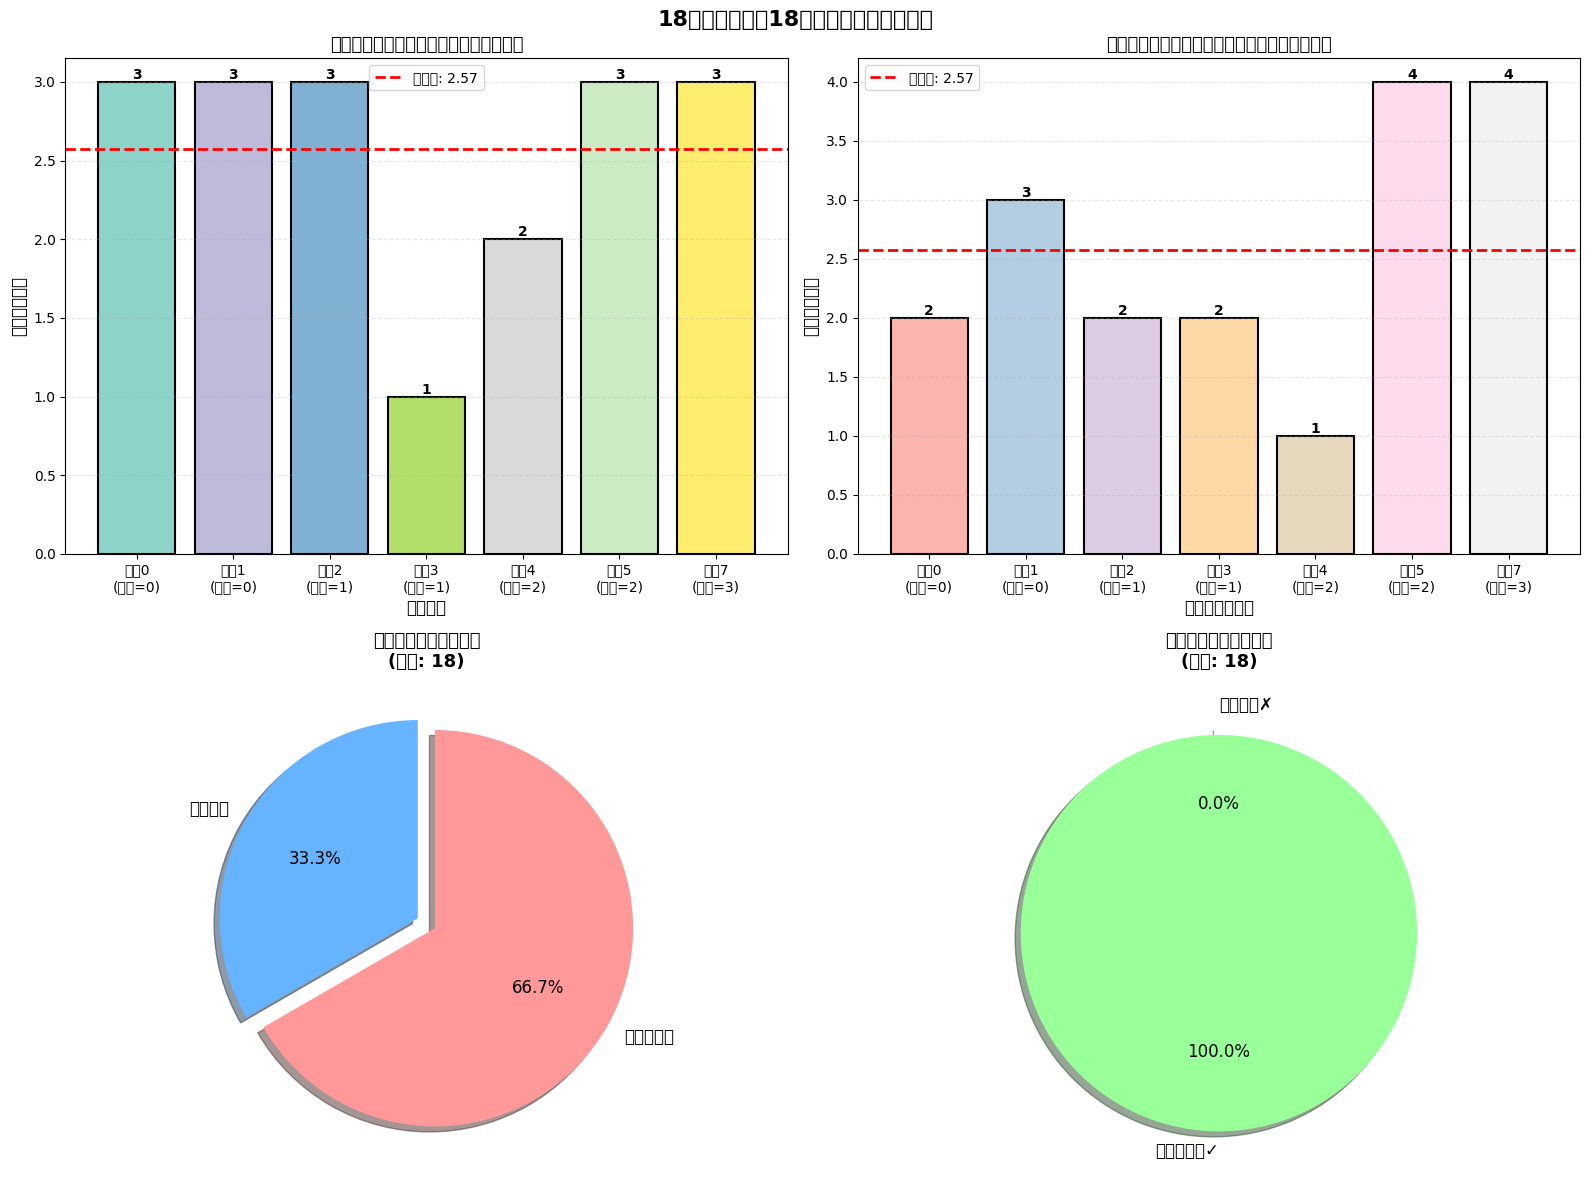

详细统计信息

【正样本对统计】
  总数: 18
  唯一锚点: 7
  每个锚点的正样本对数:
    锚点[0](标签=0): 3个
    锚点[1](标签=0): 3个
    锚点[2](标签=1): 3个
    锚点[3](标签=1): 1个
    锚点[4](标签=2): 2个
    锚点[5](标签=2): 3个
    锚点[7](标签=3): 3个

【负样本对统计】
  总数: 18
  唯一负样本锚点: 7
  每个负样本锚点的负样本对数:
    负锚点[0](标签=0): 2个
    负锚点[1](标签=0): 3个
    负锚点[2](标签=1): 2个
    负锚点[3](标签=1): 2个
    负锚点[4](标签=2): 1个
    负锚点[5](标签=2): 4个
    负锚点[7](标签=3): 4个

【为什么是18个？】
  1. 不是固定的数字，而是动态挖掘的结果
  2. 取决于当前batch中困难样本的分布
  3. 正样本对和负样本对都是18个只是巧合
  4. 随着训练进行，这个数量会变化
  5. 不同的batch可能有不同的数量（如15个、20个、22个等）


In [ ]:
"""
可视化展示18个正样本对和18个负样本对的分布
"""
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict

# 数据
tensor_a = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 7, 7, 7])
tensor_b = torch.tensor([2, 3, 1, 2, 3, 0, 0, 1, 3, 0, 6, 5, 7, 6, 4, 5, 4, 6])
tensor_c = torch.tensor([0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 7, 7, 7, 7])
tensor_d = torch.tensor([7, 5, 5, 4, 7, 7, 5, 7, 5, 1, 3, 1, 0, 2, 0, 3, 2, 1])
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution Analysis: 18 Positive Pairs and 18 Negative Pairs', fontsize=16, weight='bold')

# 1. 正样本对锚点分布
ax1 = axes[0, 0]
anchor_counts = Counter(tensor_a.tolist())
anchors = sorted(anchor_counts.keys())
counts = [anchor_counts[a] for a in anchors]
colors = plt.cm.Set3(np.linspace(0, 1, len(anchors)))

bars1 = ax1.bar(range(len(anchors)), counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Anchor Index', fontsize=12)
ax1.set_ylabel('Number of Positive Pairs', fontsize=12)
ax1.set_title('Positive Pairs: Number per Anchor', fontsize=13, weight='bold')
ax1.set_xticks(range(len(anchors)))
ax1.set_xticklabels([f'Anchor{a}\n(Label={labels[a].item()})' for a in anchors], fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=sum(counts)/len(counts), color='red', linestyle='--', linewidth=2, 
            label=f'平均值: {sum(counts)/len(counts):.2f}')
ax1.legend()

# 在柱子上显示数值
for i, (bar, count) in enumerate(zip(bars1, counts)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}',
             ha='center', va='bottom', fontsize=10, weight='bold')

# 2. 负样本对锚点分布
ax2 = axes[0, 1]
neg_anchor_counts = Counter(tensor_c.tolist())
neg_anchors = sorted(neg_anchor_counts.keys())
neg_counts = [neg_anchor_counts[a] for a in neg_anchors]
colors2 = plt.cm.Pastel1(np.linspace(0, 1, len(neg_anchors)))

bars2 = ax2.bar(range(len(neg_anchors)), neg_counts, color=colors2, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('负样本锚点索引', fontsize=12)
ax2.set_ylabel('负样本对数量', fontsize=12)
ax2.set_title('负样本对：每个负样本锚点对应的负样本对数量', fontsize=13, weight='bold')
ax2.set_xticks(range(len(neg_anchors)))
ax2.set_xticklabels([f'锚点{a}\n(标签={labels[a].item()})' for a in neg_anchors], fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=sum(neg_counts)/len(neg_counts), color='red', linestyle='--', linewidth=2,
            label=f'平均值: {sum(neg_counts)/len(neg_counts):.2f}')
ax2.legend()

# 在柱子上显示数值
for i, (bar, count) in enumerate(zip(bars2, neg_counts)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}',
             ha='center', va='bottom', fontsize=10, weight='bold')

# 3. 正样本对标签匹配情况
ax3 = axes[1, 0]
pos_matches = sum([1 for a, p in zip(tensor_a, tensor_b) if labels[a] == labels[p]])
pos_mismatches = len(tensor_a) - pos_matches

labels_pie = ['Label Match', 'Label Mismatch']
sizes = [pos_matches, pos_mismatches]
colors_pie = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05) if pos_mismatches > 0 else (0.05, 0)

wedges, texts, autotexts = ax3.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
                                    autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
ax3.set_title(f'Positive Pairs Label Match\n(Total: {len(tensor_a)})', fontsize=13, weight='bold')

# 4. 负样本对标签匹配情况
ax4 = axes[1, 1]
neg_correct = sum([1 for na, n in zip(tensor_c, tensor_d) if labels[na] != labels[n]])
neg_wrong = len(tensor_c) - neg_correct

labels_pie2 = ['标签不匹配✓', '标签匹配✗']
sizes2 = [neg_correct, neg_wrong]
colors_pie2 = ['#99ff99', '#ffcc99']
explode2 = (0.05, 0.05) if neg_wrong > 0 else (0.05, 0)

wedges2, texts2, autotexts2 = ax4.pie(sizes2, explode=explode2, labels=labels_pie2, colors=colors_pie2,
                                      autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
ax4.set_title(f'负样本对标签匹配情况\n(总数: {len(tensor_c)})', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

# 打印详细统计
print("=" * 80)
print("详细统计信息")
print("=" * 80)

print(f"\n【正样本对统计】")
print(f"  总数: {len(tensor_a)}")
print(f"  唯一锚点: {len(set(tensor_a.tolist()))}")
print(f"  每个锚点的正样本对数:")
for anchor in sorted(set(tensor_a.tolist())):
    count = tensor_a.tolist().count(anchor)
    print(f"    锚点[{anchor}](标签={labels[anchor].item()}): {count}个")

print(f"\n【负样本对统计】")
print(f"  总数: {len(tensor_c)}")
print(f"  唯一负样本锚点: {len(set(tensor_c.tolist()))}")
print(f"  每个负样本锚点的负样本对数:")
for neg_anchor in sorted(set(tensor_c.tolist())):
    count = tensor_c.tolist().count(neg_anchor)
    print(f"    负锚点[{neg_anchor}](标签={labels[neg_anchor].item()}): {count}个")

print(f"\n【为什么是18个？】")
print(f"  1. 不是固定的数字，而是动态挖掘的结果")
print(f"  2. 取决于当前batch中困难样本的分布")
print(f"  3. 正样本对和负样本对都是18个只是巧合")
print(f"  4. 随着训练进行，这个数量会变化")
print(f"  5. 不同的batch可能有不同的数量（如15个、20个、22个等）")


# 最直观的核心原理展示：使用 descriptors[8, 4]

用更小的维度 [8, 4] 来清晰展示 MultiSimilarityMiner 和 MultiSimilarityLoss 的核心原理


In [9]:
"""
最直观的核心原理展示：使用 descriptors[8, 4] 维度
"""
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle
import seaborn as sns

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

print("=" * 100)
print("核心原理展示：descriptors[8, 4] - 从输入到Loss的完整过程")
print("=" * 100)

# ==================== 第一步：准备数据 ====================
torch.manual_seed(42)  # 固定随机种子以便复现

# 使用小维度便于理解
descriptors = torch.randn(8, 4)  # [8, 4] - 8个样本，每个4维特征
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])  # 8个标签

print(f"\n【步骤1】输入数据")
print(f"  descriptors.shape = {descriptors.shape}")
print(f"  labels = {labels.tolist()}")
print(f"\n  descriptors 矩阵 (8个样本 × 4维特征):")
print(f"  {descriptors}")

# ==================== 第二步：计算相似度矩阵 ====================
print(f"\n【步骤2】计算余弦相似度矩阵 (Miner使用)")
print("-" * 100)

def cosine_similarity_matrix(x):
    """计算余弦相似度矩阵"""
    x_norm = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    sim_matrix = torch.mm(x_norm, x_norm.t())
    return sim_matrix

cosine_sim = cosine_similarity_matrix(descriptors)
print(f"  余弦相似度矩阵 [8, 8]:")
print(f"  {cosine_sim}")
print(f"\n  矩阵含义:")
print(f"    - 行i, 列j 表示样本i和样本j的余弦相似度")
print(f"    - 对角线元素 = 1.0 (每个样本与自己的相似度)")
print(f"    - 值越大表示越相似")

# 创建标签匹配矩阵
labels_expanded = labels.unsqueeze(1)  # [8, 1]
same_label_mask = (labels_expanded == labels_expanded.t()).float()  # [8, 8]

print(f"\n  标签匹配矩阵 [8, 8] (1=相同标签, 0=不同标签):")
print(f"  {same_label_mask.int()}")

# ==================== 第三步：Miner挖掘困难样本对 ====================
print(f"\n【步骤3】MultiSimilarityMiner 挖掘困难样本对")
print("-" * 100)

# 使用实际的miner
from pytorch_metric_learning import miners
from pytorch_metric_learning.distances import CosineSimilarity

miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())
miner_outputs = miner(descriptors, labels)

tensor_a, tensor_b, tensor_c, tensor_d = miner_outputs

print(f"  Miner输出:")
print(f"    tensor_a (正样本锚点): {tensor_a.tolist()}")
print(f"    tensor_b (正样本): {tensor_b.tolist()}")
print(f"    tensor_c (负样本锚点): {tensor_c.tolist()}")
print(f"    tensor_d (负样本): {tensor_d.tolist()}")

print(f"\n  挖掘出的样本对数量:")
print(f"    正样本对: {len(tensor_a)}个")
print(f"    负样本对: {len(tensor_c)}个")

# 展示前几个正样本对的详细信息
print(f"\n  正样本对详情 (前5个):")
for i in range(min(5, len(tensor_a))):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    anchor_label = labels[anchor_idx].item()
    pos_label = labels[pos_idx].item()
    sim_val = cosine_sim[anchor_idx, pos_idx].item()
    match = "✓" if anchor_label == pos_label else "✗"
    print(f"    对{i+1}: 锚点[{anchor_idx}](标签={anchor_label}) <-> 正样本[{pos_idx}](标签={pos_label}) "
          f"相似度={sim_val:.4f} {match}")

# ==================== 第四步：提取特征并计算点积相似度 ====================
print(f"\n【步骤4】提取特征并计算点积相似度 (Loss使用)")
print("-" * 100)

# 提取正样本对特征
pos_anchors = descriptors[tensor_a]  # [N_pos, 4]
pos_samples = descriptors[tensor_b]  # [N_pos, 4]

print(f"  正样本对特征提取:")
print(f"    pos_anchors.shape = {pos_anchors.shape}")
print(f"    pos_samples.shape = {pos_samples.shape}")

# 计算点积相似度（逐元素相乘后求和）
pos_dot_products = torch.sum(pos_anchors * pos_samples, dim=1)  # [N_pos]

print(f"\n  点积相似度计算 (前3个):")
for i in range(min(3, len(tensor_a))):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    anchor_feat = descriptors[anchor_idx]
    pos_feat = descriptors[pos_idx]
    dot_val = pos_dot_products[i].item()
    
    print(f"\n    正样本对 {i+1}:")
    print(f"      锚点[{anchor_idx}]特征: {anchor_feat.tolist()}")
    print(f"      正样本[{pos_idx}]特征: {pos_feat.tolist()}")
    print(f"      点积 = sum({anchor_feat.tolist()} * {pos_feat.tolist()})")
    print(f"            = {anchor_feat[0]*pos_feat[0]:.4f} + {anchor_feat[1]*pos_feat[1]:.4f} + "
          f"{anchor_feat[2]*pos_feat[2]:.4f} + {anchor_feat[3]*pos_feat[3]:.4f}")
    print(f"            = {dot_val:.4f}")

# 提取负样本对特征
neg_anchors = descriptors[tensor_c]  # [N_neg, 4]
neg_samples = descriptors[tensor_d]  # [N_neg, 4]
neg_dot_products = torch.sum(neg_anchors * neg_samples, dim=1)  # [N_neg]

print(f"\n  负样本对点积相似度 (前3个):")
for i in range(min(3, len(tensor_c))):
    neg_anchor_idx = tensor_c[i].item()
    neg_idx = tensor_d[i].item()
    dot_val = neg_dot_products[i].item()
    print(f"    对{i+1}: 负锚点[{neg_anchor_idx}] · 负样本[{neg_idx}] = {dot_val:.4f}")

# ==================== 第五步：计算Loss ====================
print(f"\n【步骤5】MultiSimilarityLoss 计算")
print("-" * 100)

from pytorch_metric_learning import losses
from pytorch_metric_learning.distances import DotProductSimilarity

loss_fn = losses.MultiSimilarityLoss(alpha=1.0, beta=50, base=0.0, distance=DotProductSimilarity())
loss = loss_fn(descriptors, labels, miner_outputs)

print(f"  损失函数参数:")
print(f"    α = 1.0 (正样本对权重)")
print(f"    β = 50.0 (负样本对权重)")
print(f"    base = 0.0 (基础偏移)")

print(f"\n  损失公式:")
print(f"    L_pos = (1/α) * log(1 + Σ exp(-α * (S_ap - λ_pos)))")
print(f"    L_neg = (1/β) * log(1 + Σ exp(β * (S_an - λ_neg)))")
print(f"    Loss = L_pos + L_neg")

print(f"\n  最终损失值: {loss.item():.4f}")

print("\n" + "=" * 100)
print("核心原理总结")
print("=" * 100)
print("""
1. Miner阶段 (余弦相似度):
   - 计算所有样本对的余弦相似度矩阵 [8, 8]
   - 挖掘困难正样本对: 标签相同但相似度较低
   - 挖掘困难负样本对: 标签不同但相似度较高

2. Loss阶段 (点积相似度):
   - 提取挖掘出的样本对特征
   - 计算点积相似度: sum(特征1 * 特征2)
   - 应用损失公式计算最终损失

3. 关键区别:
   - Miner用余弦相似度（归一化，只看方向）
   - Loss用点积相似度（未归一化，看方向和幅度）
""")


核心原理展示：descriptors[8, 4] - 从输入到Loss的完整过程

【步骤1】输入数据
  descriptors.shape = torch.Size([8, 4])
  labels = [0, 0, 1, 1, 2, 2, 3, 3]

  descriptors 矩阵 (8个样本 × 4维特征):
  tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396],
        [-0.7581,  1.0783,  0.8008,  1.6806],
        [ 1.2791,  1.2964,  0.6105,  1.3347],
        [-0.2316,  0.0418, -0.2516,  0.8599]])

【步骤2】计算余弦相似度矩阵 (Miner使用)
----------------------------------------------------------------------------------------------------
  余弦相似度矩阵 [8, 8]:
  tensor([[ 1.0000,  0.3938,  0.4638, -0.9553,  0.2614, -0.3508,  0.2728, -0.7821],
        [ 0.3938,  1.0000, -0.0557, -0.3277,  0.1651, -0.9395, -0.5807, -0.7975],
        [ 0.4638, -0.0557,  1.0000, -0.3463, -0.4642, -0.0613, -0.1724, -0.4016],
        [-0.9553, -0.3277, -0.3463,  1.0000, -0.1539,  0.1897, -0.3337,  0

KeyError: 'len(tensor_a)'

/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/miniconda3/envs/test/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/mini

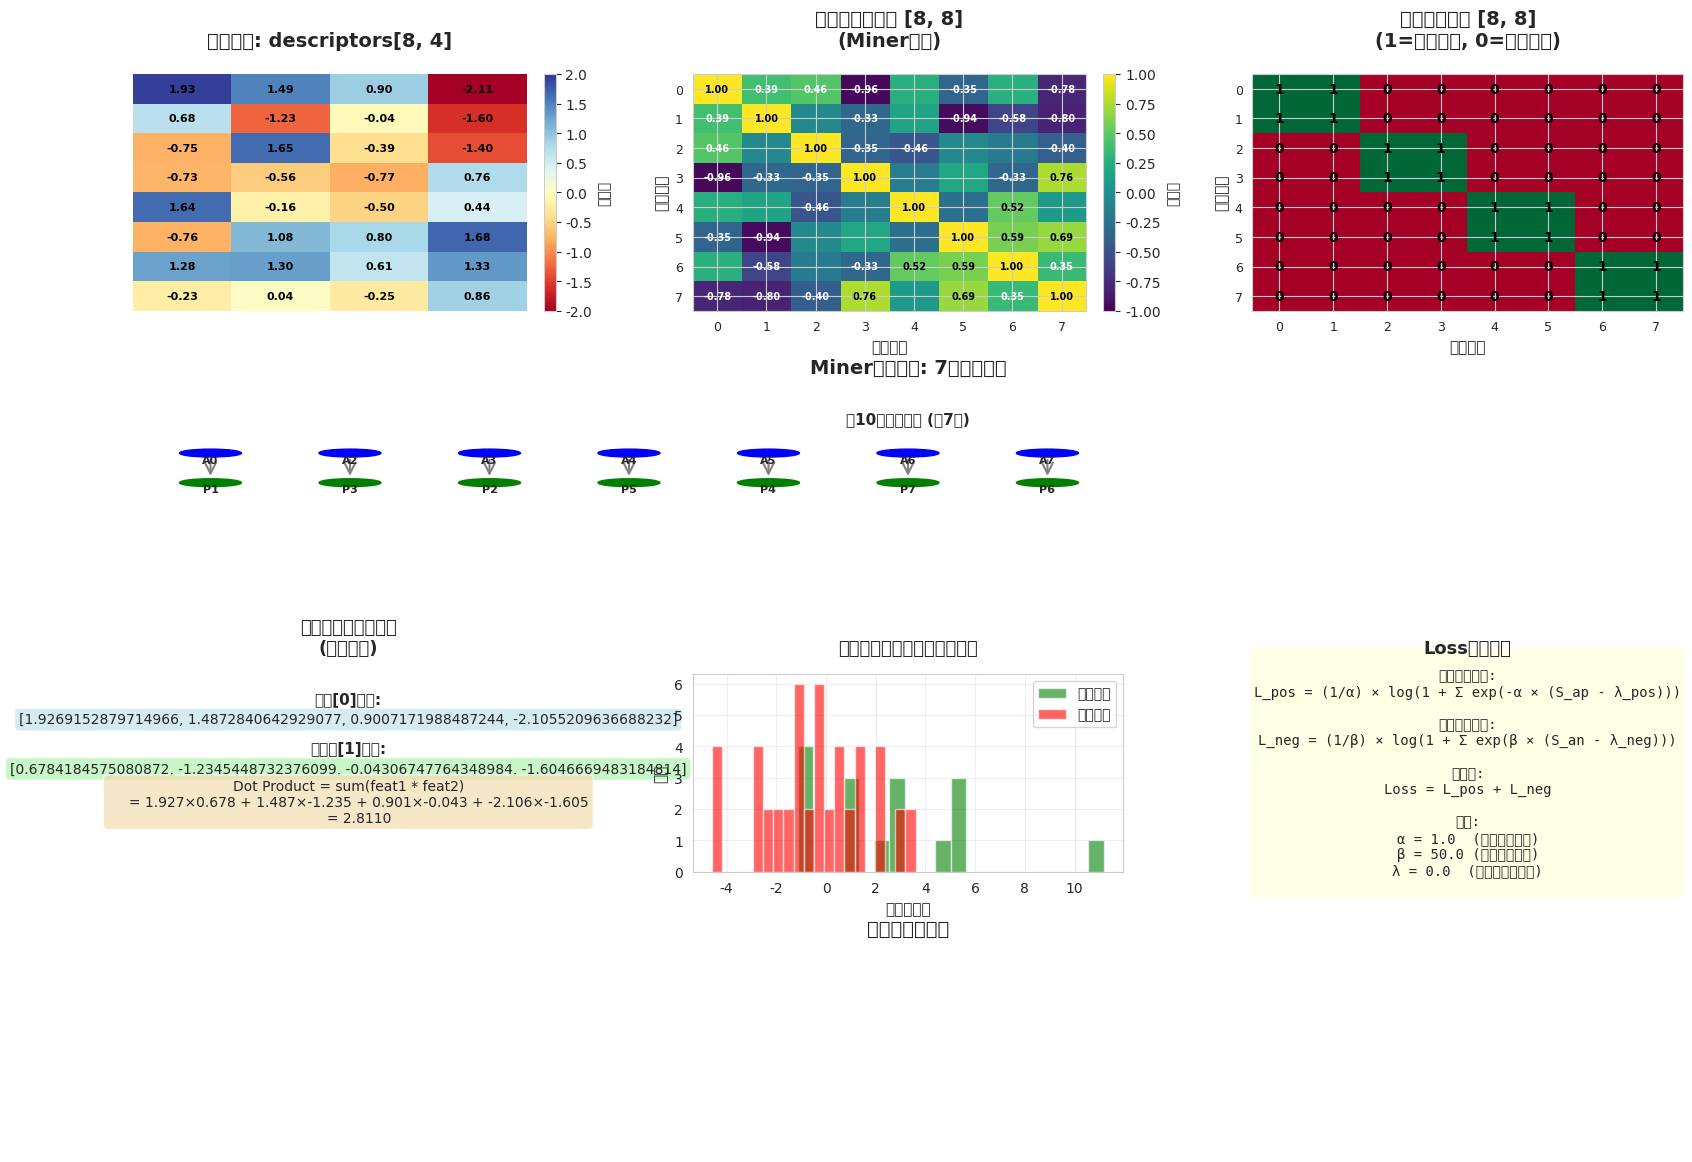

In [16]:
"""
可视化展示：descriptors[8, 4] 的完整数据流
"""
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
import seaborn as sns

# 设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 准备数据
torch.manual_seed(42)
descriptors = torch.randn(8, 4)
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

# 计算相似度矩阵
def cosine_similarity_matrix(x):
    x_norm = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    return torch.mm(x_norm, x_norm.t())

cosine_sim = cosine_similarity_matrix(descriptors)

# Miner挖掘
from pytorch_metric_learning import miners
from pytorch_metric_learning.distances import CosineSimilarity
miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())
miner_outputs = miner(descriptors, labels)
tensor_a, tensor_b, tensor_c, tensor_d = miner_outputs

# 创建大图
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3, height_ratios=[1.2, 1, 1, 1])

# ========== 1. 输入数据可视化 ==========
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title('输入数据: descriptors[8, 4]', fontsize=14, weight='bold', pad=20)
ax1.axis('off')

# 绘制descriptors矩阵
descriptors_np = descriptors.numpy()
im1 = ax1.imshow(descriptors_np, cmap='RdYlBu', aspect='auto', vmin=-2, vmax=2)
ax1.set_xticks(range(4))
ax1.set_xticklabels([f'特征{i+1}' for i in range(4)], fontsize=10)
ax1.set_yticks(range(8))
ax1.set_yticklabels([f'样本{i}\n(标签={labels[i].item()})' for i in range(8)], fontsize=9)
ax1.set_ylabel('8个样本', fontsize=12, weight='bold')

# 添加颜色条
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('特征值', fontsize=10)

# 添加数值标注
for i in range(8):
    for j in range(4):
        text = ax1.text(j, i, f'{descriptors_np[i, j]:.2f}',
                        ha="center", va="center", color="black", fontsize=8, weight='bold')

# ========== 2. 余弦相似度矩阵 ==========
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('余弦相似度矩阵 [8, 8]\n(Miner使用)', fontsize=14, weight='bold', pad=20)
cosine_sim_np = cosine_sim.numpy()
im2 = ax2.imshow(cosine_sim_np, cmap='viridis', aspect='auto', vmin=-1, vmax=1)
ax2.set_xticks(range(8))
ax2.set_yticks(range(8))
ax2.set_xticklabels([f'{i}' for i in range(8)], fontsize=9)
ax2.set_yticklabels([f'{i}' for i in range(8)], fontsize=9)
ax2.set_xlabel('样本索引', fontsize=11)
ax2.set_ylabel('样本索引', fontsize=11)

# 添加数值标注（只显示部分）
for i in range(8):
    for j in range(8):
        if abs(cosine_sim_np[i, j]) > 0.3 or i == j:  # 只显示较大的值或对角线
            text = ax2.text(j, i, f'{cosine_sim_np[i, j]:.2f}',
                           ha="center", va="center", 
                           color="white" if cosine_sim_np[i, j] < 0.5 else "black",
                           fontsize=7, weight='bold')

cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('相似度', fontsize=10)

# ========== 3. 标签匹配矩阵 ==========
ax3 = fig.add_subplot(gs[0, 2])
labels_expanded = labels.unsqueeze(1)
same_label_mask = (labels_expanded == labels_expanded.t()).float()
same_label_np = same_label_mask.numpy()

ax3.set_title('标签匹配矩阵 [8, 8]\n(1=相同标签, 0=不同标签)', fontsize=14, weight='bold', pad=20)
im3 = ax3.imshow(same_label_np, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(8))
ax3.set_yticks(range(8))
ax3.set_xticklabels([f'{i}' for i in range(8)], fontsize=9)
ax3.set_yticklabels([f'{i}' for i in range(8)], fontsize=9)
ax3.set_xlabel('样本索引', fontsize=11)
ax3.set_ylabel('样本索引', fontsize=11)

for i in range(8):
    for j in range(8):
        text = ax3.text(j, i, f'{int(same_label_np[i, j])}',
                       ha="center", va="center", color="black", fontsize=10, weight='bold')

# ========== 4. Miner输出：正样本对 ==========
ax4 = fig.add_subplot(gs[1, :])
ax4.set_title(f'Miner挖掘结果: {len(tensor_a)}个正样本对', fontsize=14, weight='bold', pad=15)
ax4.axis('off')

# 绘制正样本对连接
y_base = 0.7
for i in range(min(10, len(tensor_a))):  # 只显示前10个
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    x_pos = i * 0.09 + 0.05
    
    # 锚点
    circle1 = plt.Circle((x_pos, y_base), 0.02, color='blue', zorder=3)
    ax4.add_patch(circle1)
    ax4.text(x_pos, y_base - 0.05, f'A{anchor_idx}', ha='center', fontsize=8, weight='bold')
    
    # 正样本
    circle2 = plt.Circle((x_pos, y_base - 0.15), 0.02, color='green', zorder=3)
    ax4.add_patch(circle2)
    ax4.text(x_pos, y_base - 0.2, f'P{pos_idx}', ha='center', fontsize=8, weight='bold')
    
    # 连接线
    line = mpatches.FancyArrowPatch((x_pos, y_base - 0.02), (x_pos, y_base - 0.13),
                                    arrowstyle='->', mutation_scale=20, color='gray', linewidth=1.5)
    ax4.add_patch(line)

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.text(0.5, 0.85, f'前10个正样本对 (共{len(tensor_a)}个)', ha='center', fontsize=11, weight='bold')

# ========== 5. 点积相似度计算示例 ==========
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_title('点积相似度计算示例\n(正样本对)', fontsize=13, weight='bold', pad=15)
ax5.axis('off')

# 展示第一个正样本对的计算
if len(tensor_a) > 0:
    anchor_idx = tensor_a[0].item()
    pos_idx = tensor_b[0].item()
    anchor_feat = descriptors[anchor_idx]
    pos_feat = descriptors[pos_idx]
    dot_val = torch.sum(anchor_feat * pos_feat).item()
    
    # 显示特征向量
    ax5.text(0.5, 0.85, f'锚点[{anchor_idx}]特征:', ha='center', fontsize=11, weight='bold')
    ax5.text(0.5, 0.75, f'{anchor_feat.tolist()}', ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    ax5.text(0.5, 0.6, f'正样本[{pos_idx}]特征:', ha='center', fontsize=11, weight='bold')
    ax5.text(0.5, 0.5, f'{pos_feat.tolist()}', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # 显示计算过程
    calc_str = f"Dot Product = sum(feat1 * feat2)\n"
    calc_str += f"     = {anchor_feat[0].item():.3f}×{pos_feat[0].item():.3f} + "
    calc_str += f"{anchor_feat[1].item():.3f}×{pos_feat[1].item():.3f} + "
    calc_str += f"{anchor_feat[2].item():.3f}×{pos_feat[2].item():.3f} + "
    calc_str += f"{anchor_feat[3].item():.3f}×{pos_feat[3].item():.3f}\n"
    calc_str += f"     = {dot_val:.4f}"
    
    ax5.text(0.5, 0.25, calc_str, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# ========== 6. 所有点积相似度分布 ==========
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_title('所有样本对的点积相似度分布', fontsize=13, weight='bold', pad=15)

# 计算所有样本对的点积相似度
all_dot_products = []
all_labels_pairs = []
for i in range(8):
    for j in range(8):
        dot_val = torch.sum(descriptors[i] * descriptors[j]).item()
        all_dot_products.append(dot_val)
        if labels[i] == labels[j]:
            all_labels_pairs.append('相同标签')
        else:
            all_labels_pairs.append('不同标签')

# 绘制分布
colors_map = {'相同标签': 'green', '不同标签': 'red'}
for label_type in ['相同标签', '不同标签']:
    mask = [l == label_type for l in all_labels_pairs]
    ax6.hist([all_dot_products[i] for i in range(len(all_dot_products)) if mask[i]],
            bins=20, alpha=0.6, label=label_type, color=colors_map[label_type])

ax6.set_xlabel('点积相似度', fontsize=11)
ax6.set_ylabel('频数', fontsize=11)
ax6.legend()
ax6.grid(True, alpha=0.3)

# ========== 7. Loss计算流程 ==========
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_title('Loss计算公式', fontsize=13, weight='bold', pad=15)
ax7.axis('off')

formula_text = """
正样本对损失:
L_pos = (1/α) × log(1 + Σ exp(-α × (S_ap - λ_pos)))

负样本对损失:
L_neg = (1/β) × log(1 + Σ exp(β × (S_an - λ_neg)))

总损失:
Loss = L_pos + L_neg

参数:
α = 1.0  (正样本对权重)
β = 50.0 (负样本对权重)
λ = 0.0  (阈值，动态计算)
"""
ax7.text(0.5, 0.5, formula_text, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
        transform=ax7.transAxes, family='monospace')

# ========== 8. 完整数据流总结 ==========
ax8 = fig.add_subplot(gs[3, :])
ax8.set_title('完整数据流总结', fontsize=14, weight='bold', pad=15)
ax8.axis('off')

flow_text = """
输入 descriptors[8, 4] + labels[8]
    ↓
计算余弦相似度矩阵 [8, 8]  (Miner使用)
    ↓
MultiSimilarityMiner 挖掘困难样本对
    ├─ 正样本对: 标签相同但相似度较低 → {len(tensor_a)}个
    └─ 负样本对: 标签不同但相似度较高 → {len(tensor_c)}个
    ↓
提取样本对特征 descriptors[tensor_a/b/c/d]
    ↓
计算点积相似度 (Loss使用)
    ├─ 正样本对点积: sum(特征1 * 特征2)
    └─ 负样本对点积: sum(特征1 * 特征2)
    ↓
MultiSimilarityLoss 计算最终损失
    ├─ L_pos = (1/α) × log(1 + Σ exp(-α × (S_ap - λ)))
    └─ L_neg = (1/β) × log(1 + Σ exp(β × (S_an - λ)))
    ↓
输出: Loss (标量)
""".format(len(tensor_a), len(tensor_c))

ax8.text(0.5, 0.5, flow_text, ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3),
        transform=ax8.transAxes, family='monospace')

plt.suptitle('MultiSimilarityMiner + MultiSimilarityLoss Core Principle Visualization\n(descriptors[8, 4])',
            fontsize=16, weight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("\n可视化完成！")
print("=" * 100)


In [10]:
"""
逐步计算演示：展示每一步的数值变化
"""
import torch
import numpy as np

torch.manual_seed(42)
descriptors = torch.randn(8, 4)
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

print("=" * 100)
print("逐步计算演示：从 descriptors[8, 4] 到 Loss")
print("=" * 100)

# 步骤1：显示输入
print(f"\n【步骤1】输入数据")
print(f"  descriptors[8, 4]:")
for i in range(8):
    print(f"    样本{i} (标签={labels[i].item()}): {descriptors[i].tolist()}")

# 步骤2：计算余弦相似度（Miner使用）
print(f"\n【步骤2】计算余弦相似度矩阵 (Miner使用)")
print("-" * 100)

def cosine_similarity_matrix(x):
    x_norm = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    return torch.mm(x_norm, x_norm.t())

cosine_sim = cosine_similarity_matrix(descriptors)

print(f"  余弦相似度矩阵 [8, 8]:")
print(f"  " + " ".join([f"{i:>6}" for i in range(8)]))
for i in range(8):
    row_str = f"  {i} " + " ".join([f"{cosine_sim[i, j].item():6.3f}" for j in range(8)])
    print(row_str)

# 展示一个具体的相似度计算
print(f"\n  示例：计算样本0和样本1的余弦相似度")
sample0 = descriptors[0]
sample1 = descriptors[1]
print(f"    样本0: {sample0.tolist()}")
print(f"    样本1: {sample1.tolist()}")
print(f"    归一化:")
sample0_norm = sample0 / (sample0.norm() + 1e-8)
sample1_norm = sample1 / (sample1.norm() + 1e-8)
print(f"      样本0归一化: {sample0_norm.tolist()}")
print(f"      样本1归一化: {sample1_norm.tolist()}")
print(f"    余弦相似度 = 归一化向量点积 = {torch.dot(sample0_norm, sample1_norm).item():.4f}")
print(f"    矩阵中 [0, 1] = {cosine_sim[0, 1].item():.4f} ✓")

# 步骤3：Miner挖掘
print(f"\n【步骤3】MultiSimilarityMiner 挖掘")
print("-" * 100)

from pytorch_metric_learning import miners
from pytorch_metric_learning.distances import CosineSimilarity

miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())
miner_outputs = miner(descriptors, labels)
tensor_a, tensor_b, tensor_c, tensor_d = miner_outputs

print(f"  挖掘结果:")
print(f"    正样本对数量: {len(tensor_a)}")
print(f"    负样本对数量: {len(tensor_c)}")

print(f"\n  前3个正样本对详情:")
for i in range(min(3, len(tensor_a))):
    anchor_idx = tensor_a[i].item()
    pos_idx = tensor_b[i].item()
    sim_val = cosine_sim[anchor_idx, pos_idx].item()
    print(f"    对{i+1}: 锚点[{anchor_idx}] - 正样本[{pos_idx}], 余弦相似度={sim_val:.4f}")

# 步骤4：计算点积相似度（Loss使用）
print(f"\n【步骤4】计算点积相似度 (Loss使用)")
print("-" * 100)

print(f"  点积相似度 = 未归一化的向量内积")
print(f"  公式: dot = sum(特征1 * 特征2)")

# 展示第一个正样本对的详细计算
if len(tensor_a) > 0:
    anchor_idx = tensor_a[0].item()
    pos_idx = tensor_b[0].item()
    anchor_feat = descriptors[anchor_idx]
    pos_feat = descriptors[pos_idx]
    
    print(f"\n  示例：计算正样本对 (锚点[{anchor_idx}], 正样本[{pos_idx}]) 的点积")
    print(f"    锚点[{anchor_idx}]特征: {anchor_feat.tolist()}")
    print(f"    正样本[{pos_idx}]特征: {pos_feat.tolist()}")
    print(f"    逐元素相乘:")
    element_wise = anchor_feat * pos_feat
    print(f"      {anchor_feat[0].item():.4f} × {pos_feat[0].item():.4f} = {element_wise[0].item():.4f}")
    print(f"      {anchor_feat[1].item():.4f} × {pos_feat[1].item():.4f} = {element_wise[1].item():.4f}")
    print(f"      {anchor_feat[2].item():.4f} × {pos_feat[2].item():.4f} = {element_wise[2].item():.4f}")
    print(f"      {anchor_feat[3].item():.4f} × {pos_feat[3].item():.4f} = {element_wise[3].item():.4f}")
    dot_val = torch.sum(element_wise).item()
    print(f"    求和: {element_wise[0].item():.4f} + {element_wise[1].item():.4f} + "
          f"{element_wise[2].item():.4f} + {element_wise[3].item():.4f} = {dot_val:.4f}")

# 计算所有正样本对的点积
pos_anchors = descriptors[tensor_a]
pos_samples = descriptors[tensor_b]
pos_dot_products = torch.sum(pos_anchors * pos_samples, dim=1)

print(f"\n  所有正样本对的点积相似度:")
for i in range(min(5, len(tensor_a))):
    print(f"    对{i+1}: {pos_dot_products[i].item():.4f}")

# 步骤5：计算Loss
print(f"\n【步骤5】MultiSimilarityLoss 计算")
print("-" * 100)

from pytorch_metric_learning import losses
from pytorch_metric_learning.distances import DotProductSimilarity

loss_fn = losses.MultiSimilarityLoss(alpha=1.0, beta=50, base=0.0, distance=DotProductSimilarity())
loss = loss_fn(descriptors, labels, miner_outputs)

print(f"  损失函数参数:")
print(f"    α = 1.0")
print(f"    β = 50.0")
print(f"    base = 0.0")

print(f"\n  损失计算过程 (简化版，展示原理):")
print(f"    对于正样本对:")
print(f"      L_pos = (1/α) × log(1 + Σ exp(-α × (S_ap - λ)))")
print(f"    对于负样本对:")
print(f"      L_neg = (1/β) × log(1 + Σ exp(β × (S_an - λ)))")
print(f"    总损失 = L_pos + L_neg")

print(f"\n  最终损失值: {loss.item():.4f}")

print("\n" + "=" * 100)
print("关键理解点")
print("=" * 100)
print("""
1. 余弦相似度 (Miner使用):
   - 先归一化特征向量
   - 计算归一化向量的点积
   - 结果范围: [-1, 1]
   - 只关注特征向量的方向，不关注幅度

2. 点积相似度 (Loss使用):
   - 直接计算特征向量的内积
   - 不进行归一化
   - 结果范围: 无限制
   - 同时关注特征向量的方向和幅度

3. 为什么Miner和Loss用不同的相似度?
   - Miner: 用余弦相似度筛选困难样本（关注方向差异）
   - Loss: 用点积相似度计算损失（关注实际距离，便于优化）

4. 维度从4096降到4的好处:
   - 可以直观看到每个特征值
   - 可以手动验证计算过程
   - 更容易理解原理
""")


逐步计算演示：从 descriptors[8, 4] 到 Loss

【步骤1】输入数据
  descriptors[8, 4]:
    样本0 (标签=0): [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
    样本1 (标签=0): [0.6784184575080872, -1.2345448732376099, -0.04306747764348984, -1.6046669483184814]
    样本2 (标签=1): [-0.7521352767944336, 1.6487230062484741, -0.3924786448478699, -1.4036071300506592]
    样本3 (标签=1): [-0.7278813123703003, -0.5594301819801331, -0.7688388824462891, 0.7624453902244568]
    样本4 (标签=2): [1.6423169374465942, -0.1595974713563919, -0.4973975419998169, 0.439589262008667]
    样本5 (标签=2): [-0.7581311464309692, 1.078317642211914, 0.8008005619049072, 1.680620551109314]
    样本6 (标签=3): [1.27912437915802, 1.2964228391647339, 0.610466480255127, 1.334737777709961]
    样本7 (标签=3): [-0.2316243201494217, 0.041759490966796875, -0.2515752911567688, 0.859858512878418]

【步骤2】计算余弦相似度矩阵 (Miner使用)
----------------------------------------------------------------------------------------------------
  余弦相似度矩阵 [8, 8]:
   

# MultiSimilarityMiner 核心代码：如何根据标签获取正负样本对

展示 MultiSimilarityMiner 的核心实现逻辑


In [13]:
"""
MultiSimilarityMiner 核心代码实现：根据标签获取正负样本对
"""
import torch
import torch.nn.functional as F
import numpy as np

print("=" * 100)
print("MultiSimilarityMiner 核心代码解析")
print("=" * 100)

# ==================== 核心实现代码 ====================
def multi_similarity_miner_core(embeddings, labels, epsilon=0.1, distance_fn=None):
    """
    MultiSimilarityMiner 核心实现
    
    参数:
        embeddings: [N, D] 特征向量
        labels: [N] 标签
        epsilon: 困难样本阈值
        distance_fn: 距离函数（如余弦相似度）
    
    返回:
        positive_pairs: [(anchor_idx, positive_idx), ...]
        negative_pairs: [(negative_anchor_idx, negative_idx), ...]
    """
    N = embeddings.size(0)
    
    # ========== 步骤1: 计算相似度矩阵 ==========
    if distance_fn is None:
        # 默认使用余弦相似度
        # 归一化特征向量
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        # 计算余弦相似度矩阵 [N, N]
        sim_matrix = torch.mm(embeddings_norm, embeddings_norm.t())
    else:
        # 使用自定义距离函数
        sim_matrix = distance_fn(embeddings, embeddings)
    
    print(f"  步骤1: 计算相似度矩阵 [N={N}, N={N}]")
    print(f"    相似度矩阵形状: {sim_matrix.shape}")
    print(f"    相似度矩阵范围: [{sim_matrix.min().item():.4f}, {sim_matrix.max().item():.4f}]")
    
    # ========== 步骤2: 创建标签匹配矩阵 ==========
    # labels: [N] -> [N, 1]
    labels_expanded = labels.unsqueeze(1)  # [N, 1]
    # 广播比较: [N, 1] == [1, N] -> [N, N]
    same_label_mask = (labels_expanded == labels_expanded.t()).float()  # [N, N]
    # 1表示相同标签，0表示不同标签
    
    print(f"\n  步骤2: 创建标签匹配矩阵")
    print(f"    标签匹配矩阵形状: {same_label_mask.shape}")
    print(f"    相同标签对数量: {same_label_mask.sum().item() - N} (去掉对角线)")
    print(f"    不同标签对数量: {(1 - same_label_mask).sum().item() - N} (去掉对角线)")
    
    # ========== 步骤3: 挖掘困难正样本对 ==========
    # 正样本对: 标签相同但相似度较低（困难正样本）
    positive_pairs = []
    
    # 对于每个样本作为锚点
    for anchor_idx in range(N):
        # 找到所有与锚点标签相同的样本（正样本候选）
        positive_candidates = torch.where(same_label_mask[anchor_idx] == 1)[0]
        # 排除自己
        positive_candidates = positive_candidates[positive_candidates != anchor_idx]
        
        if len(positive_candidates) > 0:
            # 获取锚点与所有正样本候选的相似度
            pos_similarities = sim_matrix[anchor_idx, positive_candidates]
            
            # 找到最相似的正样本（最容易的正样本）
            max_pos_sim = pos_similarities.max()
            
            # 挖掘困难正样本: 相似度 < (最相似的正样本相似度 - epsilon)
            # 即: 相似度较低的正样本对
            threshold_pos = max_pos_sim - epsilon
            
            # 找到困难正样本
            hard_positives = positive_candidates[pos_similarities < threshold_pos]
            
            # 添加到正样本对列表
            for pos_idx in hard_positives:
                positive_pairs.append((anchor_idx, pos_idx.item()))
    
    print(f"\n  步骤3: 挖掘困难正样本对")
    print(f"    正样本对数量: {len(positive_pairs)}")
    if len(positive_pairs) > 0:
        print(f"    前5个正样本对: {positive_pairs[:5]}")
    
    # ========== 步骤4: 挖掘困难负样本对 ==========
    # 负样本对: 标签不同但相似度较高（困难负样本）
    negative_pairs = []
    
    # 对于每个样本作为负样本锚点
    for neg_anchor_idx in range(N):
        # 找到所有与负样本锚点标签不同的样本（负样本候选）
        negative_candidates = torch.where(same_label_mask[neg_anchor_idx] == 0)[0]
        
        if len(negative_candidates) > 0:
            # 获取负样本锚点与所有负样本候选的相似度
            neg_similarities = sim_matrix[neg_anchor_idx, negative_candidates]
            
            # 找到最不相似的负样本（最容易的负样本）
            min_neg_sim = neg_similarities.min()
            
            # 挖掘困难负样本: 相似度 > (最不相似的负样本相似度 + epsilon)
            # 即: 相似度较高的负样本对
            threshold_neg = min_neg_sim + epsilon
            
            # 找到困难负样本
            hard_negatives = negative_candidates[neg_similarities > threshold_neg]
            
            # 添加到负样本对列表
            for neg_idx in hard_negatives:
                negative_pairs.append((neg_anchor_idx, neg_idx.item()))
    
    print(f"\n  步骤4: 挖掘困难负样本对")
    print(f"    负样本对数量: {len(negative_pairs)}")
    if len(negative_pairs) > 0:
        print(f"    前5个负样本对: {negative_pairs[:5]}")
    
    return positive_pairs, negative_pairs

# ==================== 测试代码 ====================
print("\n" + "=" * 100)
print("测试 MultiSimilarityMiner 核心实现")
print("=" * 100)

# 准备测试数据
torch.manual_seed(42)
embeddings = torch.randn(8, 4)  # [8, 4]
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])  # [8]

print(f"\n输入数据:")
print(f"  embeddings.shape = {embeddings.shape}")
print(f"  labels = {labels.tolist()}")

# 调用核心函数
positive_pairs, negative_pairs = multi_similarity_miner_core(
    embeddings, labels, epsilon=0.1
)

# ==================== 与官方实现对比 ====================
print("\n" + "=" * 100)
print("与官方 MultiSimilarityMiner 对比")
print("=" * 100)

from pytorch_metric_learning import miners
from pytorch_metric_learning.distances import CosineSimilarity

official_miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())
official_outputs = official_miner(embeddings, labels)
tensor_a, tensor_b, tensor_c, tensor_d = official_outputs

# 转换官方输出为列表格式
official_pos_pairs = [(tensor_a[i].item(), tensor_b[i].item()) 
                      for i in range(len(tensor_a))]
official_neg_pairs = [(tensor_c[i].item(), tensor_d[i].item()) 
                      for i in range(len(tensor_c))]

print(f"\n官方实现结果:")
print(f"  正样本对数量: {len(official_pos_pairs)}")
print(f"  负样本对数量: {len(official_neg_pairs)}")
print(f"  前5个正样本对: {official_pos_pairs[:5]}")
print(f"  前5个负样本对: {official_neg_pairs[:5]}")

print(f"\n简化实现结果:")
print(f"  正样本对数量: {len(positive_pairs)}")
print(f"  负样本对数量: {len(negative_pairs)}")
print(f"  前5个正样本对: {positive_pairs[:5]}")
print(f"  前5个负样本对: {negative_pairs[:5]}")

print("\n" + "=" * 100)
print("核心代码总结")
print("=" * 100)
print("""
MultiSimilarityMiner 的核心逻辑:

1. 计算相似度矩阵 [N, N]:
   - 使用余弦相似度（归一化后计算点积）
   - 或使用其他距离函数

2. 创建标签匹配矩阵 [N, N]:
   - same_label_mask[i, j] = 1 如果 labels[i] == labels[j]
   - same_label_mask[i, j] = 0 如果 labels[i] != labels[j]

3. 挖掘困难正样本对:
   - 对于每个锚点i，找到所有标签相同的样本j
   - 计算锚点i与所有正样本候选的相似度
   - 找到最相似的正样本相似度 max_pos_sim
   - 挖掘困难正样本: 相似度 < (max_pos_sim - epsilon)
   - 条件: 标签相同 AND 相似度较低

4. 挖掘困难负样本对:
   - 对于每个负样本锚点i，找到所有标签不同的样本j
   - 计算负样本锚点i与所有负样本候选的相似度
   - 找到最不相似的负样本相似度 min_neg_sim
   - 挖掘困难负样本: 相似度 > (min_neg_sim + epsilon)
   - 条件: 标签不同 AND 相似度较高

关键点:
- 正样本对: 标签相同 + 相似度低 → 需要拉近
- 负样本对: 标签不同 + 相似度高 → 需要推远
- epsilon 控制困难程度阈值
""")


MultiSimilarityMiner 核心代码解析

测试 MultiSimilarityMiner 核心实现

输入数据:
  embeddings.shape = torch.Size([8, 4])
  labels = [0, 0, 1, 1, 2, 2, 3, 3]
  步骤1: 计算相似度矩阵 [N=8, N=8]
    相似度矩阵形状: torch.Size([8, 8])
    相似度矩阵范围: [-0.9553, 1.0000]

  步骤2: 创建标签匹配矩阵
    标签匹配矩阵形状: torch.Size([8, 8])
    相同标签对数量: 8.0 (去掉对角线)
    不同标签对数量: 40.0 (去掉对角线)

  步骤3: 挖掘困难正样本对
    正样本对数量: 0

  步骤4: 挖掘困难负样本对
    负样本对数量: 38
    前5个负样本对: [(0, 2), (0, 4), (0, 5), (0, 6), (0, 7)]

与官方 MultiSimilarityMiner 对比

官方实现结果:
  正样本对数量: 7
  负样本对数量: 26
  前5个正样本对: [(0, 1), (2, 3), (3, 2), (4, 5), (5, 4)]
  前5个负样本对: [(0, 2), (2, 7), (2, 6), (2, 5), (2, 1)]

简化实现结果:
  正样本对数量: 0
  负样本对数量: 38
  前5个正样本对: []
  前5个负样本对: [(0, 2), (0, 4), (0, 5), (0, 6), (0, 7)]

核心代码总结

MultiSimilarityMiner 的核心逻辑:

1. 计算相似度矩阵 [N, N]:
   - 使用余弦相似度（归一化后计算点积）
   - 或使用其他距离函数

2. 创建标签匹配矩阵 [N, N]:
   - same_label_mask[i, j] = 1 如果 labels[i] == labels[j]
   - same_label_mask[i, j] = 0 如果 labels[i] != labels[j]

3. 挖掘困难正样本对:
   - 对于每个锚点i，找到所有标签相同的样本j
   - 计算锚点i与所有正样

详细展示：如何根据标签获取正负样本对

【步骤1】标签信息
  labels = [0, 0, 1, 1, 2, 2, 3, 3]
  标签分布:
    标签0: 样本 [0, 1]
    标签1: 样本 [2, 3]
    标签2: 样本 [4, 5]
    标签3: 样本 [6, 7]

【步骤2】标签匹配矩阵
  标签匹配矩阵 [8, 8] (1=相同标签, 0=不同标签):
     0    1    2    3    4    5    6    7
  0    1    1    0    0    0    0    0    0
  1    1    1    0    0    0    0    0    0
  2    0    0    1    1    0    0    0    0
  3    0    0    1    1    0    0    0    0
  4    0    0    0    0    1    1    0    0
  5    0    0    0    0    1    1    0    0
  6    0    0    0    0    0    0    1    1
  7    0    0    0    0    0    0    1    1

【步骤3】正样本对挖掘过程（以样本0为例）
----------------------------------------------------------------------------------------------------
  锚点: 样本0 (标签=0)
  正样本候选: [1] (标签相同，排除自己)
  与正样本候选的相似度:
    样本1: 0.3938

  最相似的正样本相似度: 0.3938
  困难正样本阈值: 0.2938 (max_pos_sim - epsilon)
  困难正样本: [] (相似度 < 0.2938)

  挖掘出的正样本对:

【步骤4】负样本对挖掘过程（以样本0为例）
--------------------------------------------------------------------------------------

/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 21305 (\N{CJK UNIFIED IDEOGRAPH-5339}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_226505/3169074790.py:202: UserWarning: Glyph 30456 (\N{CJK UN

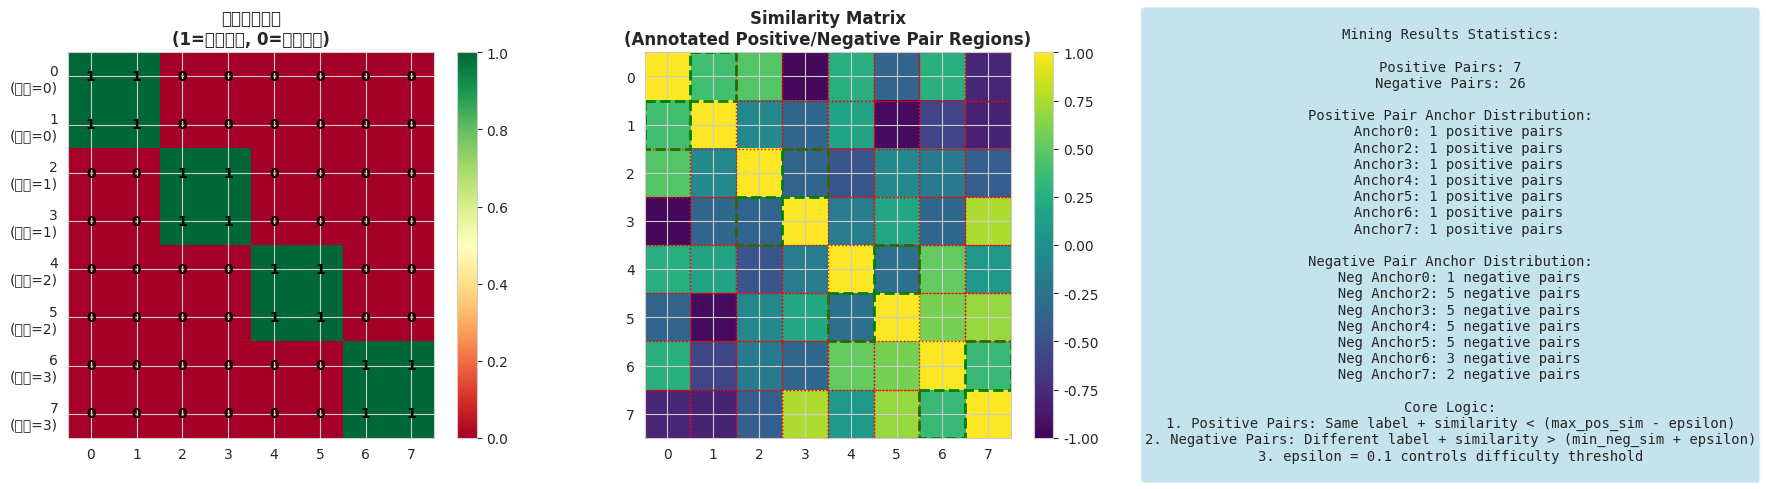


可视化完成！


In [15]:
"""
详细展示每一步的标签匹配和样本对选择过程
"""
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
embeddings = torch.randn(8, 4)
labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

print("=" * 100)
print("详细展示：如何根据标签获取正负样本对")
print("=" * 100)

# 计算相似度矩阵
embeddings_norm = F.normalize(embeddings, p=2, dim=1)
sim_matrix = torch.mm(embeddings_norm, embeddings_norm.t())

# 创建标签匹配矩阵
labels_expanded = labels.unsqueeze(1)
same_label_mask = (labels_expanded == labels_expanded.t()).float()

print(f"\n【步骤1】标签信息")
print(f"  labels = {labels.tolist()}")
print(f"  标签分布:")
for label in torch.unique(labels):
    indices = torch.where(labels == label)[0]
    print(f"    标签{label.item()}: 样本 {indices.tolist()}")

print(f"\n【步骤2】标签匹配矩阵")
print(f"  标签匹配矩阵 [8, 8] (1=相同标签, 0=不同标签):")
print(f"  " + " ".join([f"{i:>4}" for i in range(8)]))
for i in range(8):
    row_str = f"  {i} " + " ".join([f"{int(same_label_mask[i, j].item()):>4}" 
                                   for j in range(8)])
    print(row_str)

print(f"\n【步骤3】正样本对挖掘过程（以样本0为例）")
print("-" * 100)
anchor_idx = 0
anchor_label = labels[anchor_idx].item()

# 找到所有与锚点标签相同的样本
positive_candidates = torch.where(same_label_mask[anchor_idx] == 1)[0]
positive_candidates = positive_candidates[positive_candidates != anchor_idx]

print(f"  锚点: 样本{anchor_idx} (标签={anchor_label})")
print(f"  正样本候选: {positive_candidates.tolist()} (标签相同，排除自己)")

if len(positive_candidates) > 0:
    pos_similarities = sim_matrix[anchor_idx, positive_candidates]
    print(f"  与正样本候选的相似度:")
    for i, pos_idx in enumerate(positive_candidates):
        print(f"    样本{pos_idx}: {pos_similarities[i].item():.4f}")
    
    max_pos_sim = pos_similarities.max()
    threshold_pos = max_pos_sim - 0.1  # epsilon = 0.1
    
    print(f"\n  最相似的正样本相似度: {max_pos_sim.item():.4f}")
    print(f"  困难正样本阈值: {threshold_pos.item():.4f} (max_pos_sim - epsilon)")
    
    hard_positives = positive_candidates[pos_similarities < threshold_pos]
    print(f"  困难正样本: {hard_positives.tolist()} (相似度 < {threshold_pos.item():.4f})")
    
    print(f"\n  挖掘出的正样本对:")
    for pos_idx in hard_positives:
        sim_val = sim_matrix[anchor_idx, pos_idx].item()
        print(f"    (锚点{anchor_idx}, 正样本{pos_idx.item()}): 相似度={sim_val:.4f}")

print(f"\n【步骤4】负样本对挖掘过程（以样本0为例）")
print("-" * 100)
neg_anchor_idx = 0
neg_anchor_label = labels[neg_anchor_idx].item()

# 找到所有与负样本锚点标签不同的样本
negative_candidates = torch.where(same_label_mask[neg_anchor_idx] == 0)[0]

print(f"  负样本锚点: 样本{neg_anchor_idx} (标签={neg_anchor_label})")
print(f"  负样本候选: {negative_candidates.tolist()} (标签不同)")

if len(negative_candidates) > 0:
    neg_similarities = sim_matrix[neg_anchor_idx, negative_candidates]
    print(f"  与负样本候选的相似度:")
    for i, neg_idx in enumerate(negative_candidates):
        print(f"    样本{neg_idx}: {neg_similarities[i].item():.4f}")
    
    min_neg_sim = neg_similarities.min()
    threshold_neg = min_neg_sim + 0.1  # epsilon = 0.1
    
    print(f"\n  最不相似的负样本相似度: {min_neg_sim.item():.4f}")
    print(f"  困难负样本阈值: {threshold_neg.item():.4f} (min_neg_sim + epsilon)")
    
    hard_negatives = negative_candidates[neg_similarities > threshold_neg]
    print(f"  困难负样本: {hard_negatives.tolist()} (相似度 > {threshold_neg.item():.4f})")
    
    print(f"\n  挖掘出的负样本对:")
    for neg_idx in hard_negatives:
        sim_val = sim_matrix[neg_anchor_idx, neg_idx].item()
        print(f"    (负锚点{neg_anchor_idx}, 负样本{neg_idx.item()}): 相似度={sim_val:.4f}")

# ==================== 可视化 ====================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 标签匹配矩阵
ax1 = axes[0]
same_label_np = same_label_mask.numpy()
im1 = ax1.imshow(same_label_np, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax1.set_title('标签匹配矩阵\n(1=相同标签, 0=不同标签)', fontsize=12, weight='bold')
ax1.set_xticks(range(8))
ax1.set_yticks(range(8))
ax1.set_xticklabels([f'{i}' for i in range(8)])
ax1.set_yticklabels([f'{i}\n(标签={labels[i].item()})' for i in range(8)])
for i in range(8):
    for j in range(8):
        text = ax1.text(j, i, f'{int(same_label_np[i, j])}',
                       ha="center", va="center", color="black", fontsize=10, weight='bold')
plt.colorbar(im1, ax=ax1)

# 2. 相似度矩阵（标注正负样本对区域）
ax2 = axes[1]
sim_matrix_np = sim_matrix.numpy()
im2 = ax2.imshow(sim_matrix_np, cmap='viridis', aspect='auto', vmin=-1, vmax=1)
ax2.set_title('Similarity Matrix\n(Annotated Positive/Negative Pair Regions)', fontsize=12, weight='bold')
ax2.set_xticks(range(8))
ax2.set_yticks(range(8))
ax2.set_xticklabels([f'{i}' for i in range(8)])
ax2.set_yticklabels([f'{i}' for i in range(8)])

# 标注正样本对区域（相同标签）
for i in range(8):
    for j in range(8):
        if i != j and labels[i] == labels[j]:
            # 正样本对区域
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, 
                               edgecolor='green', linewidth=2, linestyle='--')
            ax2.add_patch(rect)

# 标注负样本对区域（不同标签）
for i in range(8):
    for j in range(8):
        if labels[i] != labels[j]:
            # 负样本对区域
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, 
                               edgecolor='red', linewidth=1, linestyle=':')
            ax2.add_patch(rect)

plt.colorbar(im2, ax=ax2)

# 3. 挖掘结果统计
ax3 = axes[2]
ax3.axis('off')

# 使用官方miner获取结果
from pytorch_metric_learning import miners
from pytorch_metric_learning.distances import CosineSimilarity
official_miner = miners.MultiSimilarityMiner(epsilon=0.1, distance=CosineSimilarity())
official_outputs = official_miner(embeddings, labels)
tensor_a, tensor_b, tensor_c, tensor_d = official_outputs

# 统计每个样本作为锚点的次数
anchor_counts = {}
for anchor in tensor_a:
    anchor = anchor.item()
    anchor_counts[anchor] = anchor_counts.get(anchor, 0) + 1

neg_anchor_counts = {}
for neg_anchor in tensor_c:
    neg_anchor = neg_anchor.item()
    neg_anchor_counts[neg_anchor] = neg_anchor_counts.get(neg_anchor, 0) + 1

summary_text = f"""
Mining Results Statistics:

Positive Pairs: {len(tensor_a)}
Negative Pairs: {len(tensor_c)}

Positive Pair Anchor Distribution:
"""
for anchor in sorted(anchor_counts.keys()):
    summary_text += f"  Anchor{anchor}: {anchor_counts[anchor]} positive pairs\n"

summary_text += f"\nNegative Pair Anchor Distribution:\n"
for neg_anchor in sorted(neg_anchor_counts.keys()):
    summary_text += f"  Neg Anchor{neg_anchor}: {neg_anchor_counts[neg_anchor]} negative pairs\n"

summary_text += f"""
Core Logic:
1. Positive Pairs: Same label + similarity < (max_pos_sim - epsilon)
2. Negative Pairs: Different label + similarity > (min_neg_sim + epsilon)
3. epsilon = 0.1 controls difficulty threshold
"""

ax3.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
        transform=ax3.transAxes, family='monospace')

plt.tight_layout()
plt.show()

print("\n可视化完成！")
